<a href="https://colab.research.google.com/github/catastropiyush/EquiP/blob/main/EquiP_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **EquiP: Machine Learning Model for Predicting Equilibrium Plateau Pressure of Metal Compositions**

The equilibrium plateau pressure (Peq) is a critical thermodynamic parameter, as it defines the conditions under which hydrogen absorption and desorption occur, directly influencing operating conditions of the system. However, experimentally evaluating every possible alloying combination is impractical due to the combinatorial explosion of candidate systems. Particularly, determining Van’t Hoff plots (P eq vs. 1/T) typically requires multiple pressure-temperature measurements.

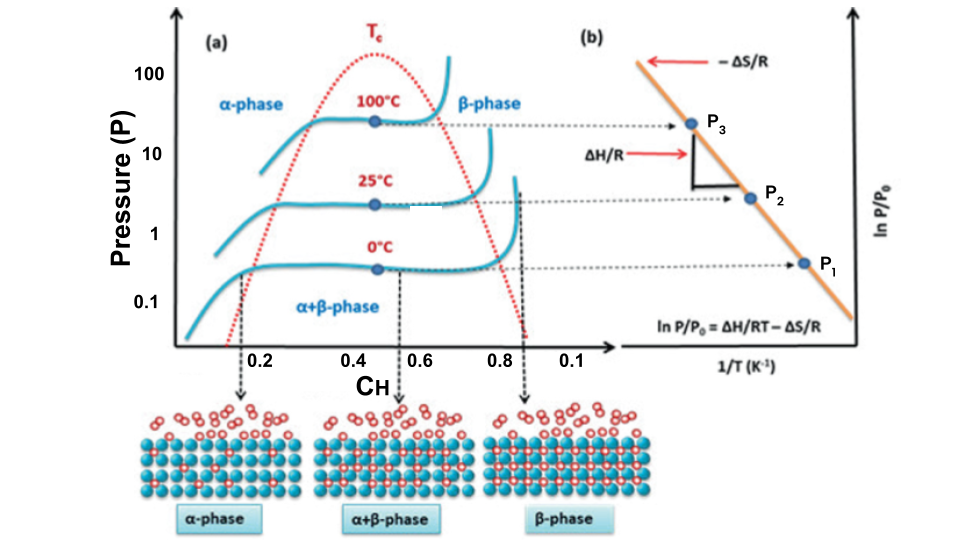

We present EquiP, an ML model trained to predict the equilibrium plateau pressure of metal compositions as a function of temperature. Through EquiP, we have also demonstrated how the incorporation of domain-informed features such as, operating conditions, hydride characteristics, and XRD information brings model predictability closer to experimental results, even with limited data. For example, including temperature as feature not only enhances model
accuracy but also enables determination of Van’t Hoff plots (Peq vs 1/T), facilitating rapid estimation of enthalpy and entropy of hydride formation.

# Step 1: Import Required Libraries
### The notebook starts by importing all the necessary Python libraries for:
### Data handling → pandas, numpy
### Machine learning → scikit-learn"
### Visualization → matplotlib, shap, plotly"


In [21]:
!sudo apt-get update
!sudo apt-get install texlive-latex-extra texlive-fonts-recommended dvipng cm-super

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://cli.github.com/packages stable InRelease [3,917 B]
Get:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:8 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease [24.6 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates/multiverse amd64 Packages [70.9 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,070 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,614 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd6

In [26]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

In [27]:
rcParams['text.usetex'] = True
rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

In [1]:
!git clone https://github.com/ashwinidverma/EquiP.git

Cloning into 'EquiP'...
remote: Enumerating objects: 55, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 55 (delta 12), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (55/55), 12.57 MiB | 9.62 MiB/s, done.
Resolving deltas: 100% (12/12), done.


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_validate, KFold, ShuffleSplit, GridSearchCV, learning_curve
from sklearn.kernel_ridge import KernelRidge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings('ignore')

# Step 2 : Load and Prepare Dataset
### Load input CSV file (EQUIP_Input_3.csv).
### Select the features and target variable (Ln(P)_Mpa).
### Standardize (normalize) feature values using StandardScaler.
### Split data into training (80%) and test (20%) sets.

In [3]:

data = pd.read_csv('/content/EquiP/Data/EQUIP_Input.csv')
Features = ['Temperature', 'CR', 'Mass', 'FIE', 'BM', 'HF', 'MV', 'M-H_Bond', 'M-H_Eng',
            'formation_H', 'vol_H', 'vol_diff', 'EN.Diff', 'Atomic.Size.Diff', 'dSmix']
scaler = StandardScaler()
data[Features] = scaler.fit_transform(data[Features])
X = data[Features]
y = data["Ln(P)_Mpa"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

In [4]:
data

,no,SrNo,PDF_name,Type,Compostion,Class,composition_final,Element,Fraction,Frac,...,en_at_H,formation_M,en_at_M,vol_H,vol_M,vol_diff,EN.Diff,M-H.EN.Diff,Atomic.Size.Diff,dSmix
0,7.0,8,MgSnZn,Lit_PCT,Mg 95 Sn 3 Zn 2,Mg+TM+Ln+,Mg0.95Sn0.03Zn0.02,Mg Sn Zn,0.95 0.03 0.02,0.95 0.03 0.02,...,-3.0775,0.0107,-1.6548,0.996448,44.7960,0.592396,-0.561847,-0.8637,-1.392488,-1.562169
1,8.0,9,MgSnZn,Lit_PCT,Mg 95 Sn 3 Zn 2,Mg+TM+Ln+,Mg0.95Sn0.03Zn0.02,Mg Sn Zn,0.95 0.03 0.02,0.95 0.03 0.02,...,-3.0775,0.0107,-1.6548,0.996448,44.7960,0.592396,-0.561847,-0.8637,-1.392488,-1.562169
2,9.0,10,MgSnZn,Lit_PCT,Mg 95 Sn 3 Zn 2,Mg+TM+Ln+,Mg0.95Sn0.03Zn0.02,Mg Sn Zn,0.95 0.03 0.02,0.95 0.03 0.02,...,-3.0775,0.0107,-1.6548,0.996448,44.7960,0.592396,-0.561847,-0.8637,-1.392488,-1.562169
3,10.0,39,17,PCI,Mg-0.05In,Mg+TM+Ln+,In0.05Mg0.95,Mg In,0.95 0.05,0.95 0.05,...,-3.0700,0.0110,-1.6465,0.809785,43.8840,0.595359,-0.730777,-0.8665,-1.531292,-1.653565
4,11.0,40,17,PCI,Mg-0.05In,Mg+TM+Ln+,In0.05Mg0.95,Mg In,0.95 0.05,0.95 0.05,...,-3.0700,0.0110,-1.6465,0.809785,43.8840,0.595359,-0.730777,-0.8665,-1.531292,-1.653565
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
288,217.0,393,244,PCT,(TiZr 0.1 ) 1.1 Cr 1.5 Fe 0.2 Mn 0.3,TM,Cr0.47Fe0.06Mn0.09Ti0.34Zr0.03,Ti Zr Cr Fe Mn,0.34 0.03 0.47 0.06 0.09,0.34 0.03 0.47 0.06 0.09,...,-6.2698,0.0000,-8.8962,0.120542,61.5001,-0.295827,-0.837470,-0.5850,-0.211707,1.100957
289,218.0,394,244,PCT,(TiZr 0.1 ) 1.1 Cr 1.5 Fe 0.2 Mn 0.3,TM,Cr0.47Fe0.06Mn0.09Ti0.34Zr0.03,Ti Zr Cr Fe Mn,0.34 0.03 0.47 0.06 0.09,0.34 0.03 0.47 0.06 0.09,...,-6.2698,0.0000,-8.8962,0.120542,61.5001,-0.295827,-0.837470,-0.5850,-0.211707,1.100957
290,187.0,352,182,PCT,TiZrNbTa,TM,Nb0.25Ta0.25Ti0.25Zr0.25,Ti Zr Nb Ta,0.25 0.25 0.25 0.25,0.25 0.25 0.25 0.25,...,-6.7700,0.0000,-9.6000,-0.375196,29.5075,0.497598,-0.750535,-0.7075,-0.808752,1.573458
291,188.0,353,182,PCT,TiZrNbTa,TM,Nb0.25Ta0.25Ti0.25Zr0.25,Ti Zr Nb Ta,0.25 0.25 0.25 0.25,0.25 0.25 0.25 0.25,...,-6.7700,0.0000,-9.6000,-0.375196,29.5075,0.497598,-0.750535,-0.7075,-0.808752,1.573458


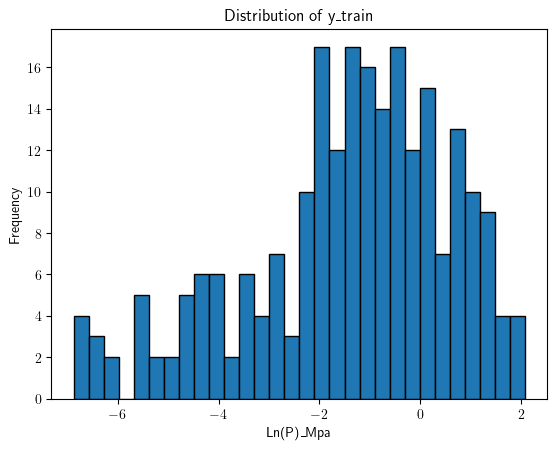

In [28]:
import matplotlib.pyplot as plt
plt.hist(y_train, bins=30, edgecolor='black')
plt.title('Distribution of y_train')
plt.xlabel('Ln(P)_Mpa')
plt.ylabel('Frequency')
plt.show()

In [6]:
display(data.describe())

,no,SrNo,Temperature_in_plot,Pressure_plot,Temperature(oC)_graph,Temperature,Temperature_1,Ln(P)_Mpa,Ln(P)_bar,Pressure(MPa),...,en_at_H,formation_M,en_at_M,vol_H,vol_M,vol_diff,EN.Diff,M-H.EN.Diff,Atomic.Size.Diff,dSmix
count,289.000000,293.000000,293.000000,293.000000,293.000000,2.930000e+02,293.000000,293.000000,293.000000,293.000000,...,293.000000,293.000000,293.000000,2.930000e+02,293.000000,2.930000e+02,2.930000e+02,293.000000,2.930000e+02,2.930000e+02
mean,162.273356,200.703072,2.449549,2.581807,219.921867,9.700242e-17,444.767918,-1.326520,0.980965,1.133208,...,-4.788347,0.003397,-5.537458,-3.395085e-16,52.735294,-4.850121e-17,8.487712e-17,-0.650309,1.333783e-16,1.940048e-16
std,97.361180,159.091052,0.805141,5.840405,158.473995,1.001711e+00,143.230586,1.979791,1.945431,1.734232,...,1.271747,0.004624,2.838350,1.001711e+00,33.886313,1.001711e+00,1.001711e+00,0.158720,1.001711e+00,1.001711e+00
min,3.000000,0.000000,0.202900,-4.132800,0.440000,-1.201292e+00,273.000000,-6.866800,-4.564200,0.000000,...,-6.770000,0.000000,-9.600000,-2.001757e+00,22.524200,-3.345192e+00,-1.447002e+00,-0.910000,-1.531292e+00,-1.653565e+00
25%,75.000000,53.000000,1.671800,0.579400,59.710000,-9.145508e-01,314.000000,-2.286800,0.090000,0.120000,...,-6.016800,0.000000,-8.710000,-7.985795e-01,34.435400,1.470994e-01,-8.374696e-01,-0.838800,-8.714993e-01,-8.333875e-01
50%,164.000000,222.000000,2.689385,1.673200,275.160000,-5.368913e-01,368.000000,-1.073300,1.151300,0.470000,...,-4.683700,0.000000,-5.576300,-1.422153e-01,42.055200,2.881115e-01,-3.188241e-01,-0.595000,-2.117066e-01,-4.007007e-02
75%,248.000000,360.000000,3.187600,3.116800,338.160000,1.043683e+00,594.000000,0.122700,2.422000,1.360000,...,-3.321200,0.009000,-2.145400,6.393140e-01,49.109500,5.890952e-01,1.135359e+00,-0.524500,6.154111e-01,7.573319e-01
max,330.000000,448.000000,3.700900,62.705400,653.000000,1.652135e+00,681.000000,2.072600,4.375200,15.480000,...,-3.010000,0.014000,-1.646500,2.090404e+00,166.075400,6.664571e-01,1.881221e+00,-0.416100,2.119434e+00,1.863559e+00


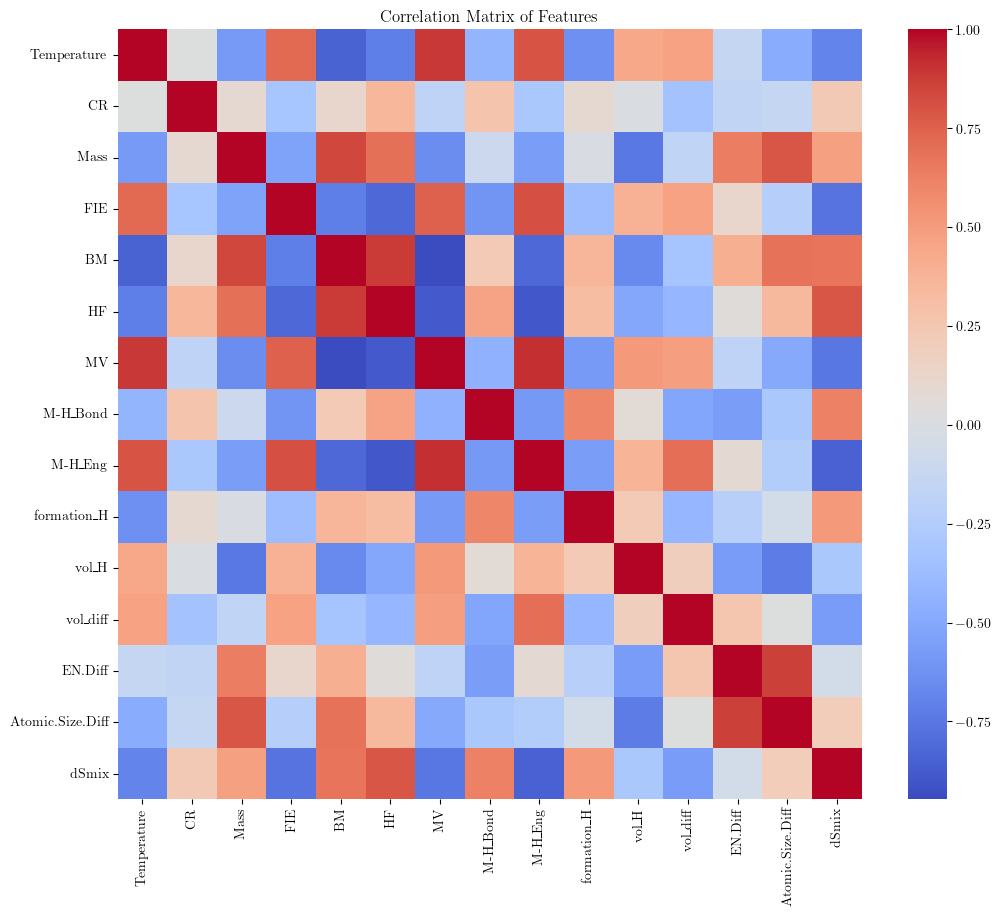

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = X.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

In [8]:
correlated_features = set()
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > 0.8: # Adjust threshold as needed
            colname1 = correlation_matrix.columns[i]
            colname2 = correlation_matrix.columns[j]
            correlated_features.add((colname1, colname2, correlation_matrix.iloc[i, j]))

if correlated_features:
    print("Features with high absolute correlation (>0.8):")
    for feature_pair in correlated_features:
        print(f"- {feature_pair[0]} and {feature_pair[1]} (Correlation: {feature_pair[2]:.2f})")
else:
    print("No features with high absolute correlation (>0.8) found.")

Features with high absolute correlation (>0.8):
- MV and BM (Correlation: -0.95)
- BM and Temperature (Correlation: -0.84)
- HF and FIE (Correlation: -0.82)
- MV and Temperature (Correlation: 0.89)
- HF and BM (Correlation: 0.88)
- Atomic.Size.Diff and EN.Diff (Correlation: 0.87)
- M-H_Eng and MV (Correlation: 0.91)
- dSmix and M-H_Eng (Correlation: -0.85)
- MV and HF (Correlation: -0.88)
- M-H_Eng and FIE (Correlation: 0.81)
- BM and Mass (Correlation: 0.84)
- M-H_Eng and HF (Correlation: -0.90)
- M-H_Eng and BM (Correlation: -0.82)
- M-H_Eng and Temperature (Correlation: 0.80)


<Figure size 1500x1500 with 0 Axes>

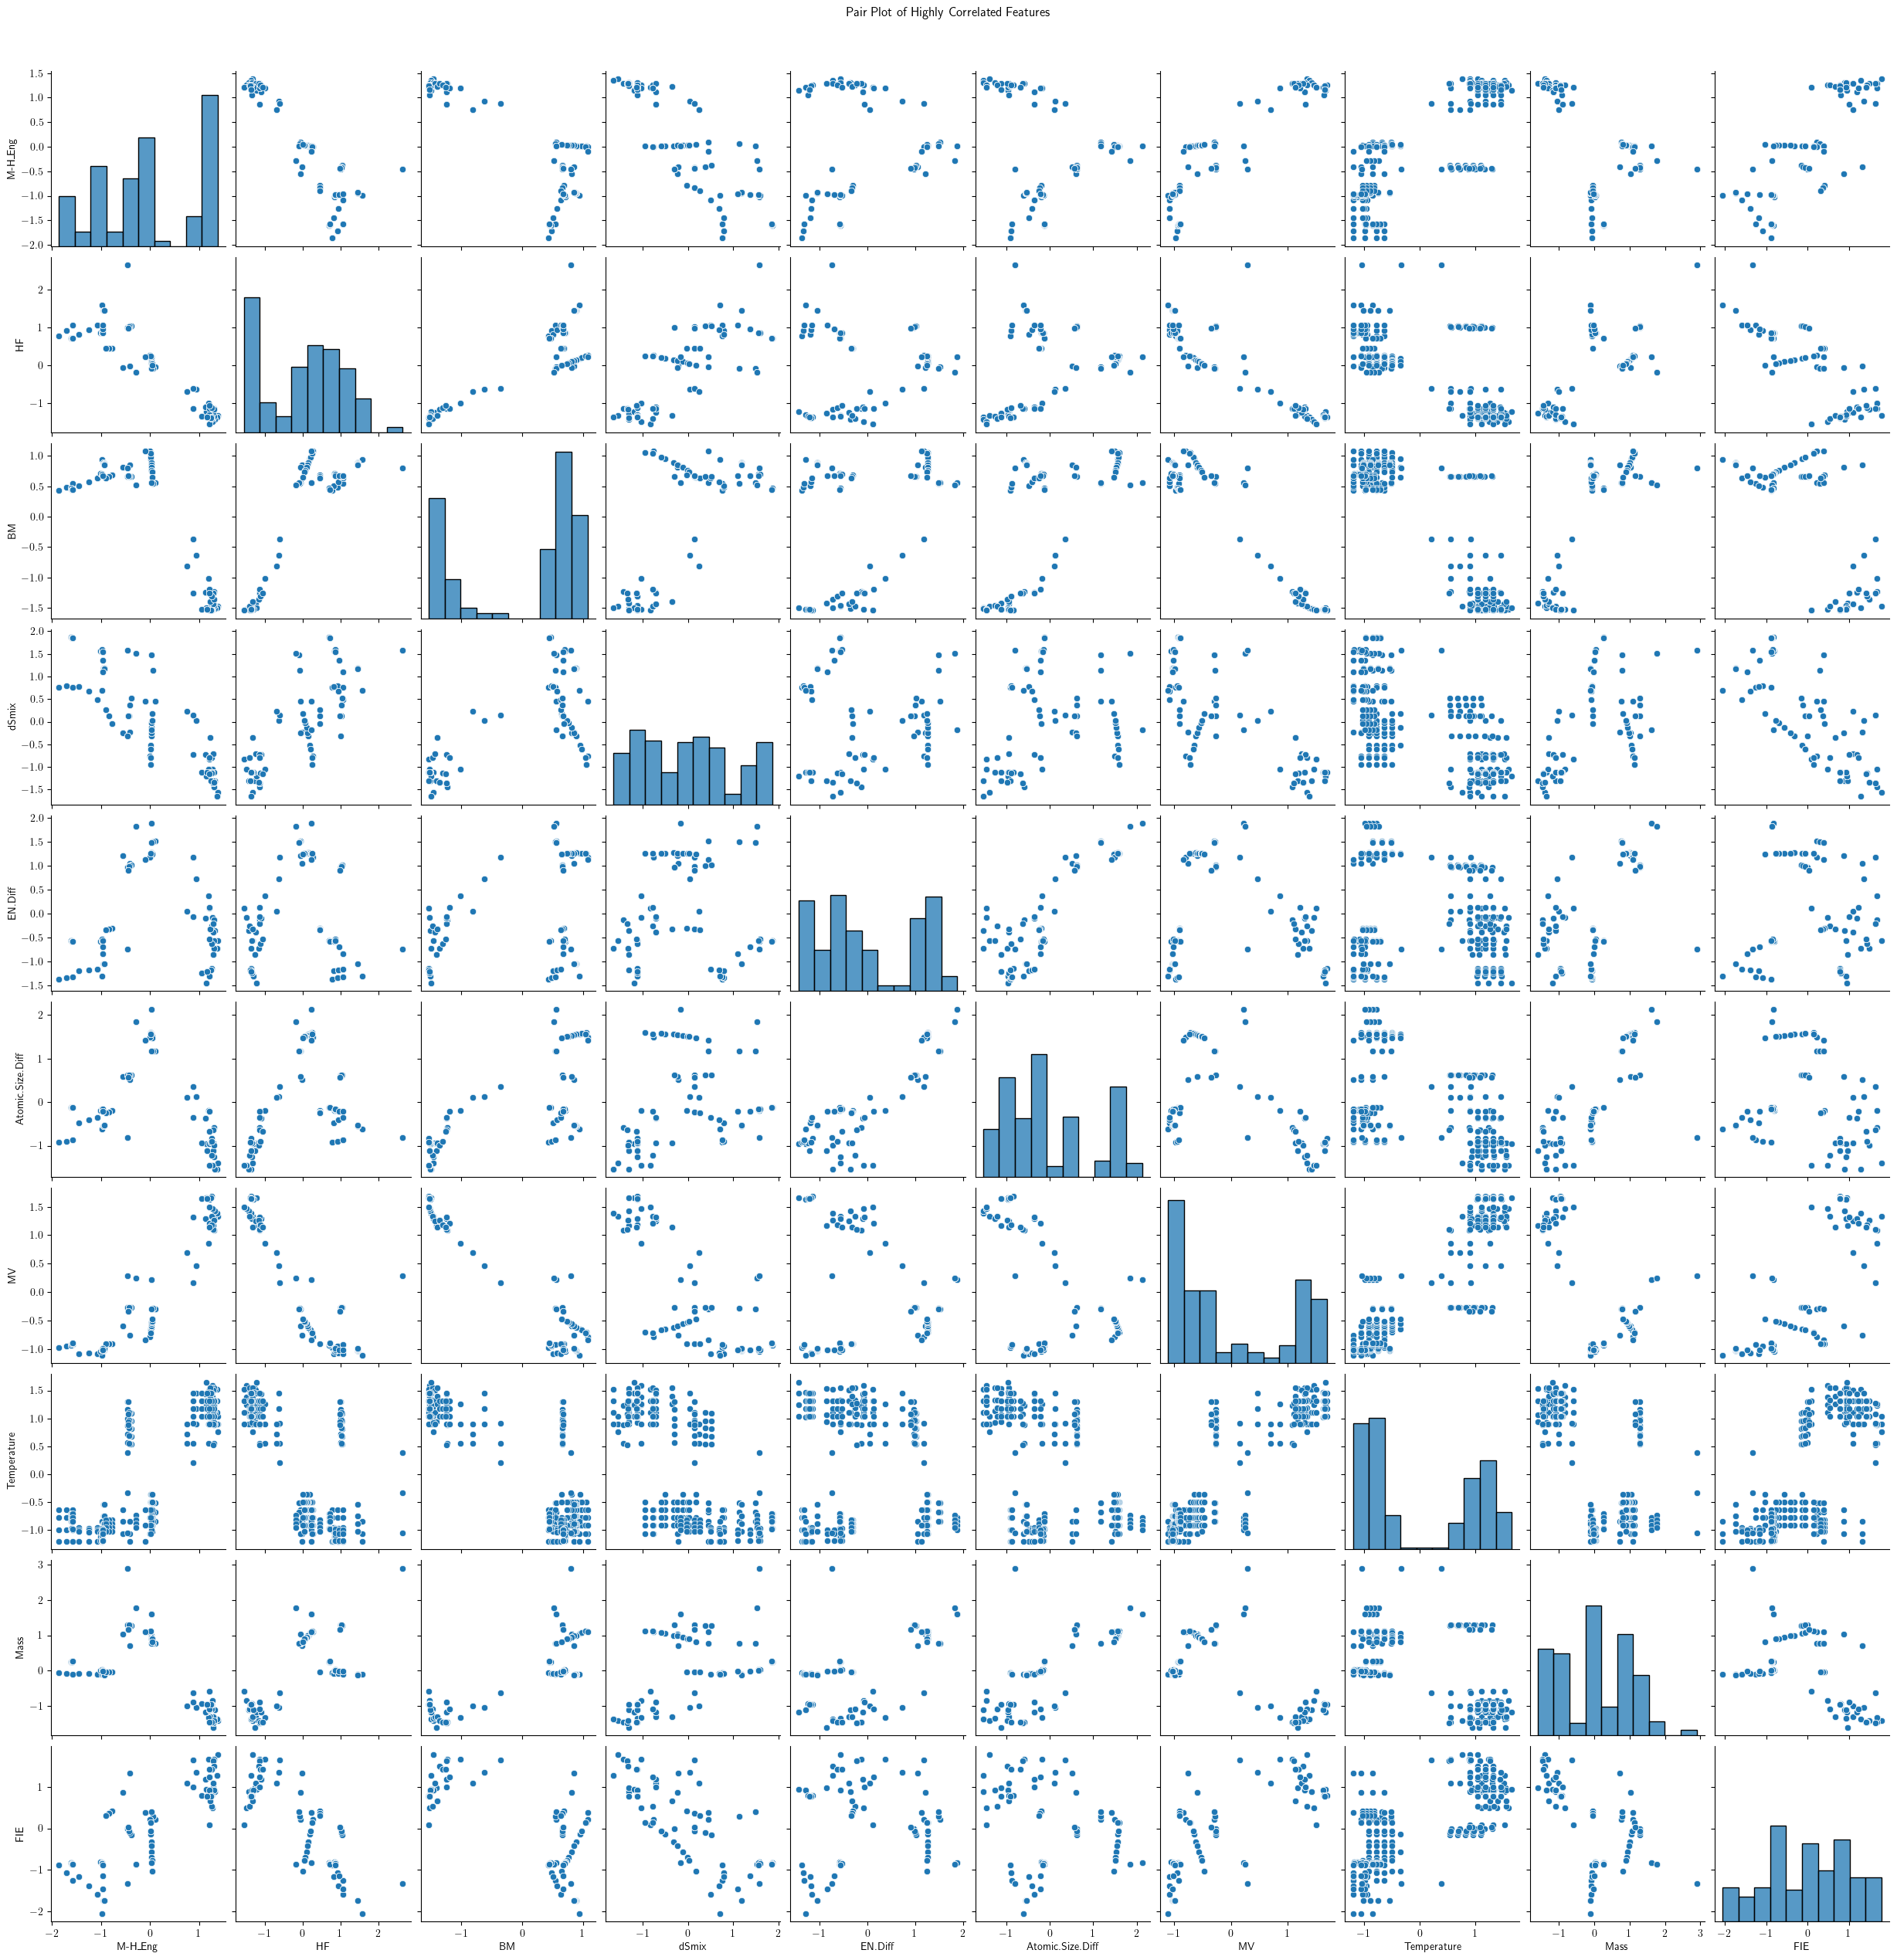

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Extract all unique features from the correlated_features set
all_correlated_feature_names = set()
for feature_pair in correlated_features:
    all_correlated_feature_names.add(feature_pair[0])
    all_correlated_feature_names.add(feature_pair[1])

# Convert to a list for consistent ordering
all_correlated_feature_names_list = list(all_correlated_feature_names)

# Create a DataFrame with only the highly correlated features
X_correlated = X[all_correlated_feature_names_list]

# Generate the pair plot
plt.figure(figsize=(15, 15)) # Adjust figure size if needed
sns.pairplot(X_correlated)
plt.suptitle('Pair Plot of Highly Correlated Features', y=1.02) # Add a title
plt.show()

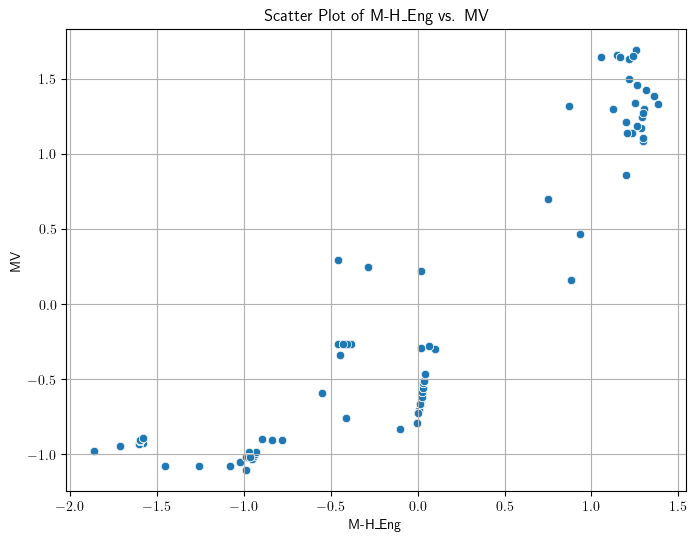

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X['M-H_Eng'], y=X['MV'])
plt.title('Scatter Plot of M-H_Eng vs. MV')
plt.xlabel('M-H_Eng')
plt.ylabel('MV')
plt.grid(True)
plt.show()

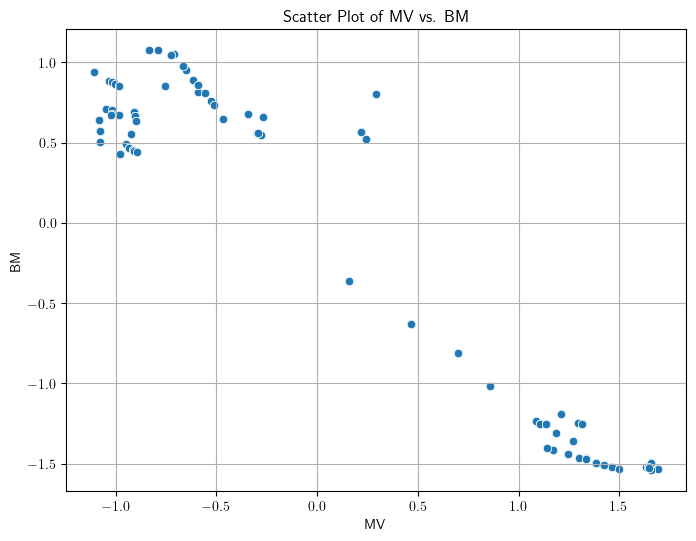

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X['MV'], y=X['BM'])
plt.title('Scatter Plot of MV vs. BM')
plt.xlabel('MV')
plt.ylabel('BM')
plt.grid(True)
plt.show()

In [34]:
# Dataset Overview
# Total points (unique composition–temperature pairs)
# Number of unique compositions
# This gives an overview of dataset diversity and coverage.
Vant_Hoff_Points = len(data.drop_duplicates(['composition_final', 'Temperature']))
Unique_Compositions = len(data['composition_final'].unique())
total = data.shape[0]
print("No of Van't Hoff Plot data points:", Vant_Hoff_Points, "; No of unique composition:", Unique_Compositions)

No of Van't Hoff Plot data points: 293 ; No of unique composition: 77


# Step 3: Hyperparameter Optimization (Grid Search)
### Perform a GridSearchCV to find the best combination of:
### alpha (regularization strength)
### kernel type (linear, rbf, poly)
### gamma (kernel coefficient)
### The best estimator (model configuration) is printed.

In [33]:
param_grid = {
    'alpha': [0.005, 0.001, 0.05, 0.01, 0.5, 0.1, 1.0, 5],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': [0.005, 0.001, 0.05, 0.01, 0.5, 0.1, 1.0, 5]
}
grid = GridSearchCV(KernelRidge(), param_grid, cv=5)
grid.fit(X_train, y_train)
print(grid.best_estimator_)

mae_train = mean_absolute_error(y_train, grid.predict(X_train))
mae_test = mean_absolute_error(y_test, grid.predict(X_test))
score_rr = grid.score(X_test, y_test)

print("MSE_train: %0.2f" % mae_train, "MAE_Test: %0.2f" % mae_test, grid.best_params_)

KernelRidge(alpha=0.001, gamma=0.1, kernel='rbf')
MSE_train: 0.09 MAE_Test: 0.11 {'alpha': 0.001, 'gamma': 0.1, 'kernel': 'rbf'}


# Step 4: Train and Evaluate the Optimized Model
### Train the Kernel Ridge Regression (KRR) model using best hyperparameters.
### MAE (Mean Absolute Error) for train and test data
### R2 Score (model fit accuracy)
### Parity Plot to visualize how well predicted values match experimental ones:
### Blue = training data
### Red = validation data



In [48]:
X_train

,Temperature,CR,Mass,FIE,BM,HF,MV,M-H_Bond,M-H_Eng,formation_H,vol_H,vol_diff,EN.Diff,Atomic.Size.Diff,dSmix
175,-0.956513,-0.860243,1.774794,-0.868478,0.522932,-0.179091,0.244376,-0.583409,-0.286460,-0.675223,-0.816895,-0.043766,1.830838,1.839926,1.515196
213,-0.886576,-0.095506,-0.113930,-1.739039,0.863384,1.449405,-1.001440,1.048901,-0.935393,0.176533,-0.347523,0.662733,-1.051843,-0.534948,1.178400
10,0.896816,0.358976,-1.100248,0.882844,-1.510940,-1.425096,1.424221,-0.380698,1.312339,-0.073927,0.838634,0.610594,-0.349449,-1.531292,-1.309711
87,1.456311,-0.638872,-0.959033,0.785076,-1.534195,-1.363599,1.691497,-0.348831,1.258265,-1.087239,0.672633,0.477284,-1.150633,-0.829668,-1.121397
152,-1.026450,-0.082090,0.892259,-0.769435,0.736412,0.053152,-0.514484,-0.715304,0.034613,-0.109298,-0.144016,0.231825,1.252919,1.499571,0.024400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,-0.921544,-0.114910,0.815055,-1.023632,0.649693,-0.000587,-0.468961,-0.702203,0.041896,-0.102606,0.392533,0.260349,1.246991,1.471050,0.172882
123,-0.494929,-0.036809,1.055454,-0.138194,0.954078,0.189423,-0.649333,-0.750358,0.017232,-0.100694,-1.412806,0.173169,1.264773,1.566121,-0.518747
15,1.526248,0.593763,-0.582680,0.092199,-1.534195,-1.551816,1.500460,-0.357683,1.215779,0.566562,0.896334,0.641065,0.112887,-1.453334,-0.833388
125,-0.774677,-0.036809,1.055454,-0.138194,0.954078,0.189423,-0.649333,-0.750358,0.017232,-0.100694,-1.412806,0.173169,1.264773,1.566121,-0.518747


In [57]:
print(X_train.describe())

       Temperature          CR        Mass         FIE          BM  \
count   234.000000  234.000000  234.000000  234.000000  234.000000   
mean      0.028133   -0.015295    0.015350    0.017344   -0.016486   
std       1.000864    1.022663    1.015588    0.998646    1.021378   
min      -1.201292   -4.085221   -1.602547   -2.050621   -1.541171   
25%      -0.886576   -0.103892   -0.959033   -0.832772   -1.253835   
50%      -0.508917    0.112449   -0.046311    0.092199    0.563210   
75%       1.094388    0.476370    0.973856    0.874768    0.760597   
max       1.652135    1.759317    2.895532    1.781885    1.076224   

               HF          MV    M-H_Bond     M-H_Eng  formation_H  \
count  234.000000  234.000000  234.000000  234.000000   234.000000   
mean    -0.023803    0.036040   -0.049791    0.048603    -0.050711   
std      1.021437    1.011590    0.971366    0.987419     0.982229   
min     -1.551816   -1.107161   -0.775144   -1.860540    -1.933258   
25%     -1.143924  

In [49]:
len(X_test)

59

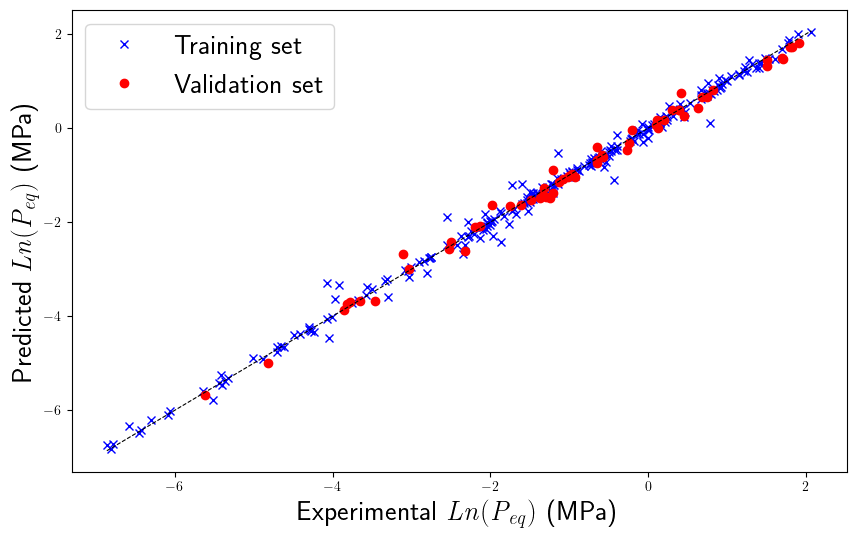

In [35]:
kr = KernelRidge(kernel='rbf', alpha=0.001, gamma=0.1)
kr.fit(X_train, y_train)
y_train_pred = kr.predict(X_train)
y_pred = kr.predict(X_test)

plt.figure(figsize=(10,6))
plt.plot(y_train, y_train_pred, 'xb', label='Training set')
plt.plot(y_test, y_pred, 'or', label='Validation set')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], '--', lw=0.8, color='black')
plt.legend(loc='upper left', fontsize=20)
plt.xlabel('Experimental $\\it{Ln(P_{eq})}$ (MPa)', fontsize=20)
plt.ylabel('Predicted $\\it{Ln(P_{eq})}$ (MPa)', fontsize=20)
#plt.savefig('OUTPUT/KRR_ML_EXP.png', format='png', dpi=800, bbox_inches='tight')
plt.show()

In [44]:
import joblib

# Save the model
joblib.dump(kr, 'KRR_hydrogen_model.pkl')

# Save the scaler (ESSENTIAL: you must scale new data exactly like the old data)
joblib.dump(scaler, 'material_scaler.pkl')

print("Model and Scaler saved successfully!")

Model and Scaler saved successfully!


In [53]:
prediction = kr.predict(X_test.iloc[[0]])
print(f"Predicted Pressure: {np.exp(prediction)[0]:.4f} MPa")

Predicted Pressure: 1.4698 MPa


In [55]:
from scipy.stats import linregress

# 1. Prepare 1/T and Ln(P)
inv_T = 1 / temp_range  # temp_range from our previous sweep
ln_P = prediction      # predictions from the model

# 2. Linear Regression (Van't Hoff Plot)
slope, intercept, r_value, p_value, std_err = linregress(inv_T, ln_P)

# 3. Extract Constants (R = 8.314 J/mol*K)
R = 8.314
delta_H = slope * R / 1000  # in kJ/mol H2
delta_S = intercept * R     # in J/mol K

print(f"Predicted Enthalpy (ΔH): {delta_H:.2f} kJ/mol")
print(f"Predicted Entropy (ΔS): {delta_S:.2f} J/mol·K")

Predicted Enthalpy (ΔH): 0.00 kJ/mol
Predicted Entropy (ΔS): 3.20 J/mol·K


In [60]:
X_test

,Temperature,CR,Mass,FIE,BM,HF,MV,M-H_Bond,M-H_Eng,formation_H,vol_H,vol_diff,EN.Diff,Atomic.Size.Diff,dSmix
286,-1.194299,0.396273,-0.005287,-1.151155,0.679647,0.961159,-1.019553,2.199131,-0.973741,1.588477,0.349113,-0.272551,-0.702128,-0.211707,1.365244
127,-0.494929,-0.031778,1.073587,-0.068056,0.978263,0.204564,-0.664316,-0.754253,0.015301,-0.099738,-1.553782,0.166652,1.264773,1.577530,-0.603705
181,-0.781671,0.683201,-0.077293,-1.075492,0.488980,0.922328,-0.947985,-0.008383,-1.712281,0.050347,-0.361888,-2.672887,-1.348212,-0.892415,0.789061
59,-1.061418,-3.026647,0.713223,1.321950,0.854012,-0.020015,-0.756640,-0.703620,-0.410773,0.646862,-0.142215,0.478300,1.045461,0.520340,-0.224202
253,1.085646,1.197503,1.161158,0.036938,0.675601,0.980959,-0.341823,-0.608195,-0.446969,-1.182834,-0.628010,0.341859,0.905179,0.567876,0.131873
244,0.826879,1.214274,1.283731,-0.107588,0.657578,1.031042,-0.268449,-0.605539,-0.408070,-1.374025,-1.008743,0.257641,1.004957,0.615411,0.370051
111,1.316438,0.102705,-1.451537,1.426094,-1.311936,-1.107550,1.187441,-0.423188,1.260307,-0.783245,0.752459,0.589095,-0.626060,-0.892415,-1.128357
98,1.036690,-2.055984,-0.943794,0.774449,-1.529544,-1.354282,1.646988,-0.350602,1.165845,-1.087239,0.659785,0.472629,-1.210894,-1.120585,-1.121397
65,0.721974,0.173292,-1.007565,1.088157,-0.811082,-0.683223,0.698678,0.263374,0.750695,0.340001,0.579551,0.557355,0.051637,0.102028,0.235196
184,-0.641797,0.528358,-0.091194,-1.259550,0.551769,1.067148,-0.923704,-0.108234,-1.578643,-0.224012,-0.422887,-2.035794,-1.324502,-0.871499,0.757332


In [63]:
results = data.loc[X_test.index, ['composition_final']].copy()
results['Actual_LnP'] = y_test
results['Predicted_LnP'] = kr.predict(X_test)

results.head()

,composition_final,Actual_LnP,Predicted_LnP
286,Cr0.4Fe0.12Mn0.09Ti0.34Zr0.03,0.3042,0.385097
127,Al0.03La0.17Ni0.8,0.1194,0.168113
181,Mn0.33Ti0.33V0.33,-0.2029,-0.040220
59,Co0.75Mg0.12Nd0.12,0.1227,0.011741
253,Co0.5Ti0.05Zr0.45,-3.6543,-3.670739


In [65]:
# 1. Reverse the scaling for X_test to get original physical values
X_test_raw = scaler.inverse_transform(X_test)
X_test_raw_df = pd.DataFrame(X_test_raw, columns=Features, index=X_test.index)

results = pd.DataFrame(index=X_test.index)
results['Composition'] = data.loc[X_test.index, 'composition_final']
results['Temp_Kelvin'] = X_test_raw_df['Temperature']
results['Actual_LnP'] = y_test
results['Predicted_LnP'] = kr.predict(X_test)

results.head()

,Composition,Temp_Kelvin,Actual_LnP,Predicted_LnP
286,Cr0.4Fe0.12Mn0.09Ti0.34Zr0.03,274.0,0.3042,0.385097
127,Al0.03La0.17Ni0.8,374.0,0.1194,0.168113
181,Mn0.33Ti0.33V0.33,333.0,-0.2029,-0.040220
59,Co0.75Mg0.12Nd0.12,293.0,0.1227,0.011741
253,Co0.5Ti0.05Zr0.45,600.0,-3.6543,-3.670739


In [66]:
# Example: Temperature range [-1.2, 1.6], CR range [-4.0, 1.7] in scaled units
import numpy as np

# Create 10 "random" material samples
# We'll create a matrix of random numbers between 0 and 1, then scale them to your feature space
random_samples = np.random.uniform(-1, 1, size=(10, len(Features)))
df_random = pd.DataFrame(random_samples, columns=Features)
random_preds = kr.predict(df_random)

# 4. View Results
df_random['Predicted_Ln_P'] = random_preds
df_random.head()

,Temperature,CR,Mass,FIE,BM,HF,MV,M-H_Bond,M-H_Eng,formation_H,vol_H,vol_diff,EN.Diff,Atomic.Size.Diff,dSmix,Predicted_Ln_P
0,0.766385,-0.729130,-0.335753,-0.815752,0.834585,-0.212554,-0.959258,-0.186083,-0.161018,-0.353145,-0.658876,-0.621241,-0.537454,-0.648073,0.782319,2.958015
1,0.406207,-0.478843,-0.578346,-0.324871,0.908577,-0.337505,0.827620,-0.841867,0.348851,-0.028574,-0.088722,0.900347,-0.130507,-0.200283,0.095533,-0.203326
2,0.626055,-0.114157,-0.241835,-0.227695,-0.904185,0.819763,-0.522165,0.203240,-0.839610,-0.665562,-0.484435,-0.709862,-0.222208,-0.827962,-0.801070,0.747006
3,0.777013,0.749368,0.650645,-0.068759,-0.695194,0.426924,0.121666,-0.406879,-0.466627,0.631297,0.555893,0.015972,0.936802,0.307106,0.816795,-0.063532
4,-0.990020,0.032586,-0.880935,-0.153831,0.934230,-0.818355,0.957804,-0.348807,0.315503,-0.296960,0.190530,-0.877441,0.028596,-0.670588,-0.112687,-6.627155


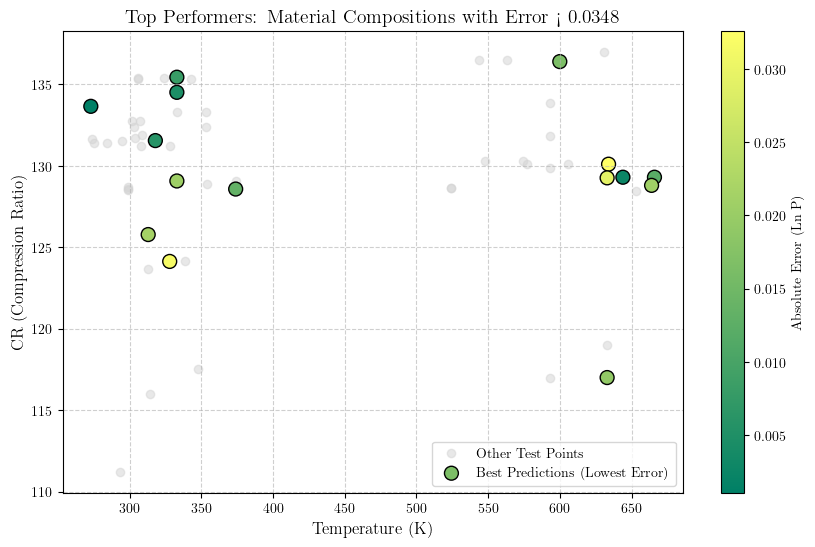

In [67]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

y_test_pred = kr.predict(X_test)
errors = np.abs(y_test - y_test_pred)

X_test_raw = scaler.inverse_transform(X_test)
X_test_raw_df = pd.DataFrame(X_test_raw, columns=Features, index=X_test.index)

analysis_df = X_test_raw_df[['Temperature', 'CR']].copy()
analysis_df['Error'] = errors
analysis_df['Composition'] = data.loc[X_test.index, 'composition_final']

threshold = analysis_df['Error'].quantile(0.25)
best_preds = analysis_df[analysis_df['Error'] <= threshold]

plt.figure(figsize=(10, 6))
plt.scatter(analysis_df['Temperature'], analysis_df['CR'],
            c='lightgrey', alpha=0.5, label='Other Test Points')

# Plot the best predictions in green
scatter = plt.scatter(best_preds['Temperature'], best_preds['CR'],
            c=best_preds['Error'], cmap='summer', s=100, edgecolor='black',
            label='Best Predictions (Lowest Error)')

plt.colorbar(scatter, label='Absolute Error (Ln P)')
plt.xlabel('Temperature (K)', fontsize=12)
plt.ylabel('CR (Compression Ratio)', fontsize=12)
plt.title(f'Top Performers: Material Compositions with Error < {threshold:.4f}', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [68]:
print("Compositions with the highest accuracy:")
print(best_preds[['Composition', 'Temperature', 'CR', 'Error']].sort_values(by='Error'))

Compositions with the highest accuracy:
                                Composition  Temperature        CR     Error
191                      Cr0.36Mn0.29Ti0.36        273.0  133.6535  0.001058
36            Al0.1Ga0.02In0.04Mg0.82Zn0.02        644.0  129.3000  0.002487
157                   La0.289Ni0.675Si0.036        333.0  134.5120  0.004594
228                     Fe0.425Mn0.075Ti0.5        318.0  131.5500  0.005747
269       Cr0.257Fe0.064Mn0.32Ti0.23Zr0.125        333.0  135.4408  0.008026
35            Al0.1Ga0.02In0.04Mg0.82Zn0.02        666.0  129.3000  0.012122
154                      Al0.17La0.17Ni0.67        374.0  128.5743  0.013297
253                       Co0.5Ti0.05Zr0.45        600.0  136.4000  0.016439
80                        Ce0.05Mg0.9Sm0.05        633.0  117.0000  0.019094
129                       Al0.03La0.17Ni0.8        333.0  129.0700  0.020570
19                               Al0.1Mg0.9        664.0  128.8000  0.020798
167                      Ce0.02La0.1

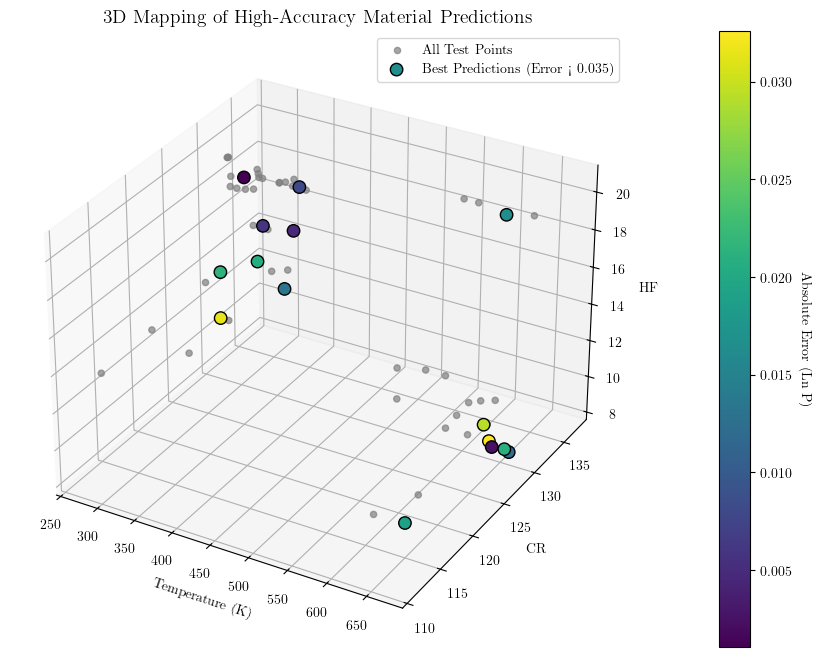

In [71]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd

# 1. Generate predictions and calculate Absolute Error
y_test_pred = kr.predict(X_test)
abs_error = np.abs(y_test - y_test_pred)

# 2. Inverse transform to get original physical units
X_test_raw = scaler.inverse_transform(X_test)
# Ensure column names match the 'Features' list used in your scaler
X_test_raw_df = pd.DataFrame(X_test_raw, columns=Features, index=X_test.index)

# 3. Create a combined DataFrame for filtering
plot_df = X_test_raw_df[['Temperature', 'CR', 'HF']].copy()
plot_df['Error'] = abs_error
plot_df['Composition'] = data.loc[X_test.index, 'composition_final']

# 4. Filter for the "Best" predictions (bottom 25% error)
threshold = plot_df['Error'].quantile(0.25)
best_points = plot_df[plot_df['Error'] <= threshold]

# 5. Create the 3D Plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot all points in the background (faded)
ax.scatter(plot_df['Temperature'], plot_df['CR'], plot_df['HF'],
           c='gray', alpha=0.7, s=20, label='All Test Points')

# Plot best points with color mapping based on error
# 'coolwarm' or 'viridis' work well here
img = ax.scatter(best_points['Temperature'], best_points['CR'], best_points['HF'],
                 c=best_points['Error'], cmap='viridis', s=80, edgecolor='k', alpha=1,
                 label=f'Best Predictions (Error < {threshold:.3f})')

# Labels and styling
ax.set_xlabel('Temperature (K)', fontsize=10)
ax.set_ylabel('CR', fontsize=10)
ax.set_zlabel('HF', fontsize=10)
ax.set_title('3D Mapping of High-Accuracy Material Predictions', fontsize=14)

# Add a colorbar to show the error scale
cbar = fig.colorbar(img, ax=ax, pad=0.1)
cbar.set_label('Absolute Error (Ln P)', rotation=270, labelpad=15)

ax.legend()
plt.show()

In [72]:
print("Top 5 Best Predicted Compositions:")
print(best_points[['Composition', 'Temperature', 'CR', 'HF', 'Error']].sort_values('Error').head(5))

Top 5 Best Predicted Compositions:
                           Composition  Temperature        CR       HF  \
191                 Cr0.36Mn0.29Ti0.36        273.0  133.6535  17.7624   
36       Al0.1Ga0.02In0.04Mg0.82Zn0.02        644.0  129.3000   8.5932   
157              La0.289Ni0.675Si0.036        333.0  134.5120  15.2379   
228                Fe0.425Mn0.075Ti0.5        318.0  131.5500  16.2050   
269  Cr0.257Fe0.064Mn0.32Ti0.23Zr0.125        333.0  135.4408  17.3712   

        Error  
191  0.001058  
36   0.002487  
157  0.004594  
228  0.005747  
269  0.008026  


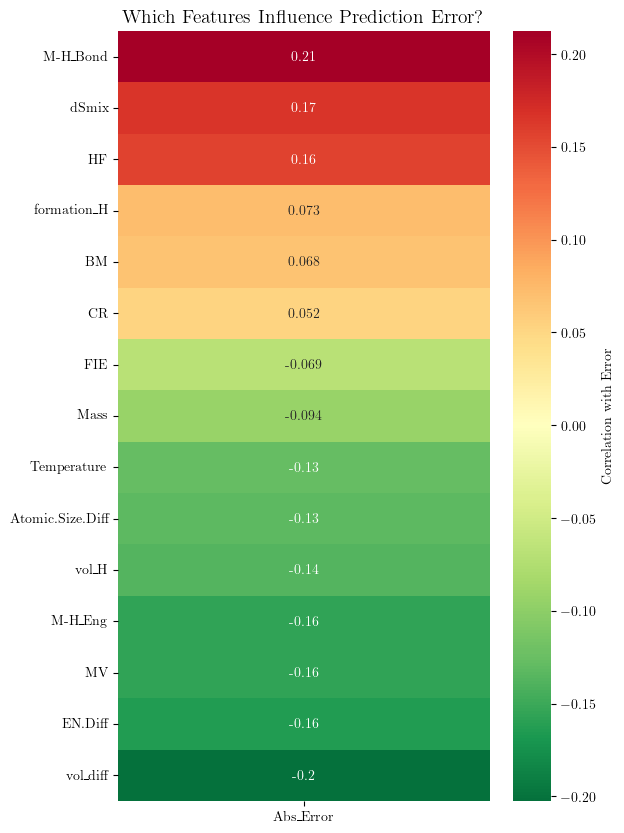

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get Absolute Error for the test set
y_test_pred = kr.predict(X_test)
abs_error = np.abs(y_test - y_test_pred)

# 2. Prepare the raw feature data
X_test_raw = scaler.inverse_transform(X_test)
X_test_raw_df = pd.DataFrame(X_test_raw, columns=Features)

# 3. Add the Error column to the dataframe
analysis_df = X_test_raw_df.copy()
analysis_df['Abs_Error'] = abs_error.values

# 4. Calculate Correlation of all features with the Error
# We want to see how much each feature influences the error magnitude
error_correlations = analysis_df.corr()[['Abs_Error']].sort_values(by='Abs_Error', ascending=False)
error_correlations = error_correlations.drop('Abs_Error') # Remove self-correlation

# 5. Plotting the Correlation Heatmap
plt.figure(figsize=(6, 10))
sns.heatmap(error_correlations, annot=True, cmap='RdYlGn_r', center=0, cbar_kws={'label': 'Correlation with Error'})
plt.title('Which Features Influence Prediction Error?', fontsize=14)
plt.show()

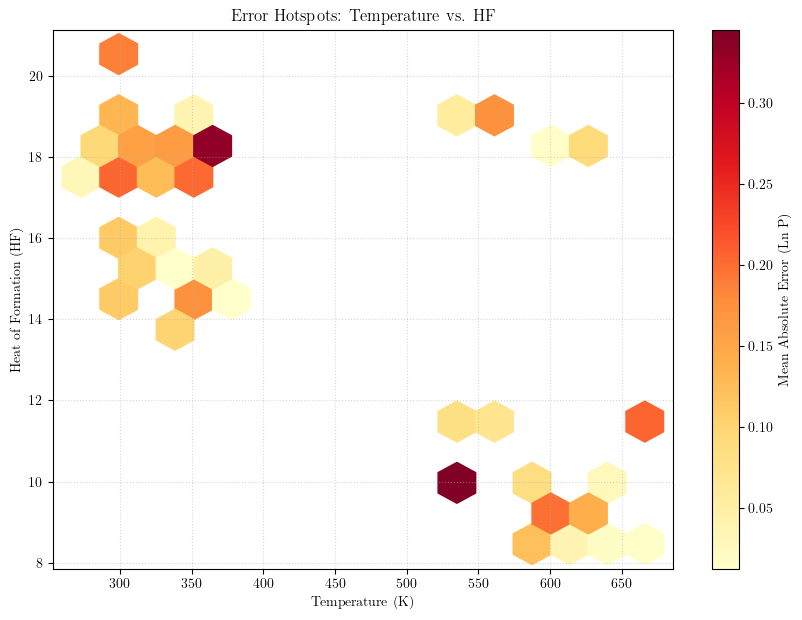

In [74]:
# Assuming Temperature and HF are the most interesting features
plt.figure(figsize=(10, 7))
hb = plt.hexbin(analysis_df['Temperature'], analysis_df['HF'],
                C=analysis_df['Abs_Error'], gridsize=15, cmap='YlOrRd', reduce_C_function=np.mean)

plt.colorbar(hb, label='Mean Absolute Error (Ln P)')
plt.xlabel('Temperature (K)')
plt.ylabel('Heat of Formation (HF)')
plt.title('Error Hotspots: Temperature vs. HF')
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

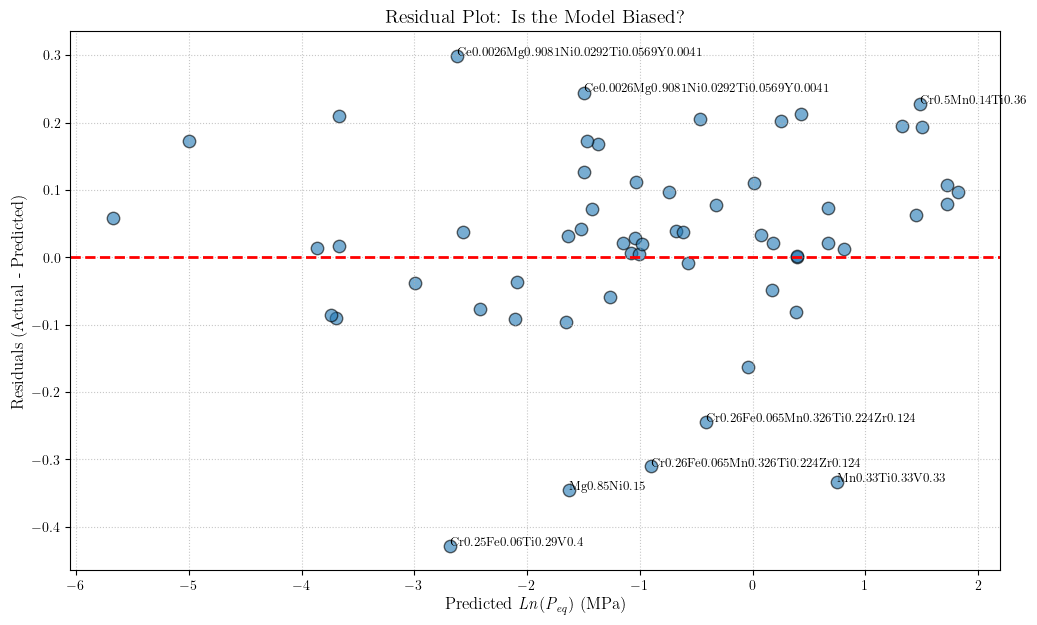

In [77]:
# 1. Calculate Residuals
y_test_pred = kr.predict(X_test)
residuals = y_test - y_test_pred

# 2. Create a Results DataFrame
res_df = pd.DataFrame({
    'Composition': data.loc[X_test.index, 'composition_final'],
    'Predicted': y_test_pred,
    'Residual': residuals
})

# 3. Plotting
plt.figure(figsize=(12, 7))
plt.axhline(y=0, color='red', linestyle='--', linewidth=2) # The "Perfect Prediction" line

# Scatter plot of residuals
plt.scatter(res_df['Predicted'], res_df['Residual'], alpha=0.6, s=80, edgecolors='k')

# Label only the high-error outliers to keep the plot clean
for i in range(len(res_df)):
    if abs(res_df['Residual'].iloc[i]) > res_df['Residual'].std() * 1.5:
        plt.text(res_df['Predicted'].iloc[i], res_df['Residual'].iloc[i],
                 res_df['Composition'].iloc[i], fontsize=9)

plt.xlabel('Predicted $\it{Ln(P_{eq})}$ (MPa)', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.title('Residual Plot: Is the Model Biased?', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

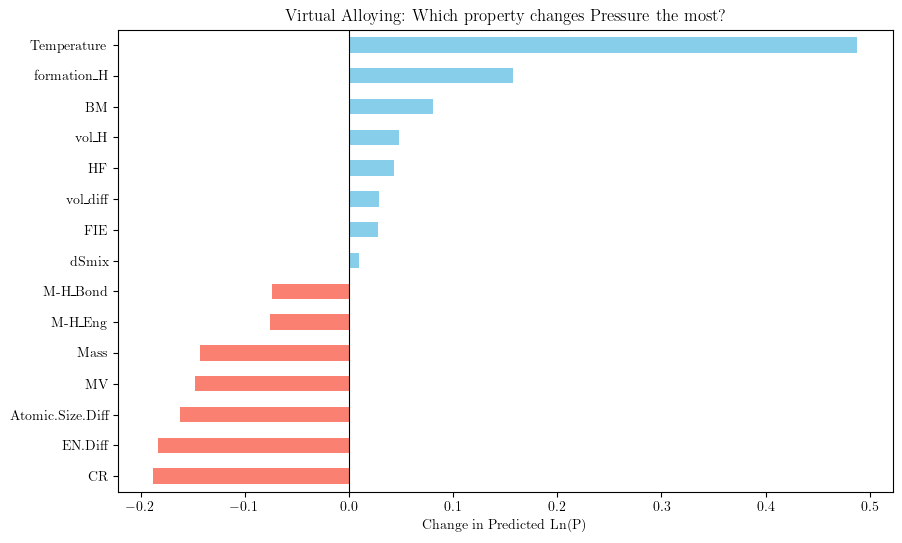

In [79]:
# Select a base material
base_material = X_test.iloc[[0]].copy()
base_pred = kr.predict(base_material)[0]

sensitivities = {}
for col in Features:
    # Increase feature by 10% of its range
    perturbed = base_material.copy()
    perturbed[col] += 0.1
    new_pred = kr.predict(perturbed)[0]
    sensitivities[col] = new_pred - base_pred

# Sort and Plot
sens_df = pd.Series(sensitivities).sort_values()
plt.figure(figsize=(10, 6))
sens_df.plot(kind='barh', color=(sens_df > 0).map({True: 'skyblue', False: 'salmon'}))
plt.axvline(0, color='black', lw=0.8)
plt.title('Virtual Alloying: Which property changes Pressure the most?')
plt.xlabel('Change in Predicted Ln(P)')
plt.show()

In [110]:
import numpy as np
import pandas as pd

target_p_mpa = 5.0
target_ln_p = np.log(target_p_mpa)
target_temp_k = 373.15  # The raw temperature you want to test
num_candidates = 50000

# 2. Use a REAL sample as a baseline (important for KRR models)
# This ensures the 'hidden' relationships between features remain somewhat realistic
base_sample_scaled = X_test.iloc[[0]].copy()

# 3. Create 5000 'Mutated' candidates based on that real sample
candidates_scaled = pd.concat([base_sample_scaled] * num_candidates, ignore_index=True)

# 4. Apply small random 'Mutations' to the scaled parameters
# We vary the physical properties within a reasonable standard deviation range
mutation_strength = 0.3
for col in Features:
    if col != 'Temperature':
        candidates_scaled[col] += np.random.normal(0, mutation_strength, num_candidates)
    else:
        # For Temperature, we convert our raw target (373.15) to scaled units
        # We create a dummy row to use the scaler correctly
        dummy = pd.DataFrame(np.zeros((1, len(Features))), columns=Features)
        dummy['Temperature'] = target_temp_k
        scaled_temp = scaler.transform(dummy)[0, 0]
        candidates_scaled['Temperature'] = scaled_temp

# 5. Predict Pressure
preds_ln = kr.predict(candidates_scaled[Features])
candidates_scaled['Predicted_P_MPa'] = np.exp(preds_ln)

# 6. Inverse Transform to see the RAW physical values
raw_values = scaler.inverse_transform(candidates_scaled[Features])
results_df = pd.DataFrame(raw_values, columns=Features)
results_df['Predicted_P_MPa'] = candidates_scaled['Predicted_P_MPa'].values

# 7. Find the best matches
results_df['Error'] = np.abs(results_df['Predicted_P_MPa'] - target_p_mpa)
top_5 = results_df.sort_values('Error').head(5)

print(f"--- Top 5 Discoveries for {target_p_mpa} MPa at {target_temp_k} K ---")
print(top_5[['CR', 'HF', 'Mass', 'BM', 'formation_H', 'Predicted_P_MPa']])

--- Top 5 Discoveries for 5.0 MPa at 373.15 K ---
               CR         HF       Mass          BM  formation_H  \
22537  130.239058  18.502145  56.411919  147.648728    -0.078905   
45437  131.003545  17.171962  56.436426  130.584916    -0.060239   
23994  133.458187  19.366632  57.616165  143.025920    -0.096355   
23003  129.844847  18.462166  49.578714  148.741105    -0.087402   
5425   130.128466  18.519810  51.804822  133.937764    -0.103027   

       Predicted_P_MPa  
22537         4.999637  
45437         5.000873  
23994         4.999101  
23003         4.998474  
5425          5.001717  


In [111]:
# 1. Identify the 'Parent' (The original material you mutated)
# We get the raw version of the base_sample for comparison
parent_raw = scaler.inverse_transform(base_sample_scaled[Features])
parent_df = pd.DataFrame(parent_raw, columns=Features)

# 2. Calculate the "Delta" (Difference) between the Top 5 and the Parent
# This shows exactly how much the parameters shifted to hit 5.0 MPa
diff_df = top_5[Features].copy()
for col in Features:
    diff_df[col] = top_5[col] - parent_df[col].values[0]

summary = pd.DataFrame({
    'Property': Features,
    'Parent_Value': parent_df.iloc[0].values,
    'Discovery_Avg': top_5[Features].mean().values,
    'Average_Mutation': diff_df[Features].mean().values
})

print("--- Mutation Summary (How we reached 5.0 MPa) ---")
print(summary.round(4))

# 4. Identify the Parent Composition Name
parent_name = data.loc[X_test.index[10], 'composition_final']
print(f"\nOriginal Parent Alloy: {parent_name}")

--- Mutation Summary (How we reached 5.0 MPa) ---
            Property  Parent_Value  Discovery_Avg  Average_Mutation
0        Temperature      274.0000       373.1500           99.1500
1                 CR      131.6224       130.9348           -0.6876
2               Mass       52.5092        54.3696            1.8604
3                FIE        6.9855         7.0098            0.0243
4                 BM      138.1990       140.7877            2.5887
5                 HF       18.4000        18.4045            0.0045
6                 MV        8.6076         9.1265            0.5189
7           M-H_Bond        3.2402         3.2776            0.0374
8            M-H_Eng       -6.5082        -6.6788           -0.1706
9        formation_H       -0.0491        -0.0852           -0.0361
10             vol_H       53.3991        52.7254           -0.6737
11          vol_diff       -0.7574        -0.8864           -0.1290
12           EN.Diff        0.1054         0.1337            0.028

--- Mutation Summary for Mg0.68Ni0.23Ti0.09 ---
            Property  Parent_Value  Discovery_Avg  Average_Mutation
0        Temperature      274.0000       373.1500           99.1500
1                 CR      131.6224       130.9348           -0.6876
2               Mass       52.5092        54.3696            1.8604
3                FIE        6.9855         7.0098            0.0243
4                 BM      138.1990       140.7877            2.5887
5                 HF       18.4000        18.4045            0.0045
6                 MV        8.6076         9.1265            0.5189
7           M-H_Bond        3.2402         3.2776            0.0374
8            M-H_Eng       -6.5082        -6.6788           -0.1706
9        formation_H       -0.0491        -0.0852           -0.0361
10             vol_H       53.3991        52.7254           -0.6737
11          vol_diff       -0.7574        -0.8864           -0.1290
12           EN.Diff        0.1054         0.1337            0.0283


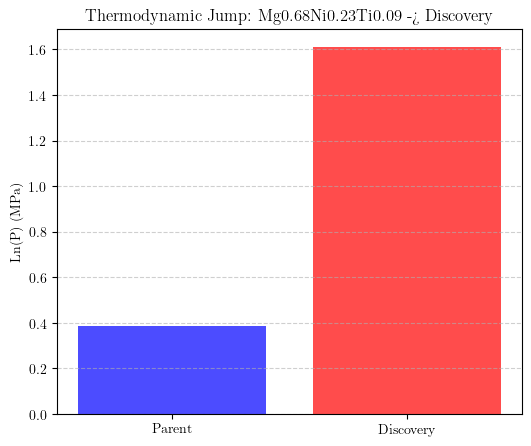

In [112]:
import numpy as np
import pandas as pd

# 1. Get the Parent's original prediction
parent_pred_lnp = kr.predict(base_sample_scaled[Features])[0]
# 2. Prepare the Summary Data
# We add Ln(P) to the features list just for this table
plot_features = Features + ['Ln(P)']
# Get average Ln(P) of top 5
discovery_avg_lnp = np.log(top_5['Predicted_P_MPa'].mean())

# 3. Create the Summary DataFrame
parent_vals = list(parent_df.iloc[0].values) + [parent_pred_lnp]
discovery_vals = list(top_5[Features].mean().values) + [discovery_avg_lnp]

summary = pd.DataFrame({
    'Property': plot_features,
    'Parent_Value': parent_vals,
    'Discovery_Avg': discovery_vals
})

summary['Average_Mutation'] = summary['Discovery_Avg'] - summary['Parent_Value']
print(f"--- Mutation Summary for {parent_name} ---")
print(summary.round(4))

# 4. Visualizing the Pressure Jump
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 5))
plt.bar(['Parent', 'Discovery'], [parent_pred_lnp, discovery_avg_lnp], color=['blue', 'red'], alpha=0.7)
plt.ylabel('Ln(P) (MPa)')
plt.title(f'Thermodynamic Jump: {parent_name} -> Discovery')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

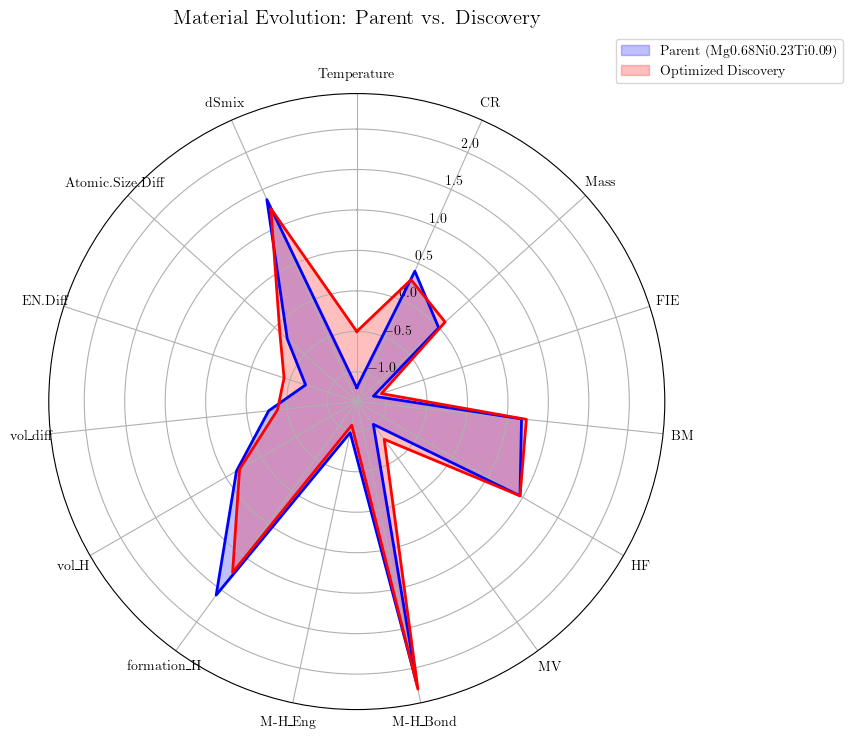

In [113]:
import matplotlib.pyplot as plt
import numpy as np

parent_scaled = base_sample_scaled.values[0]
discovery_scaled = candidates_scaled.loc[top_5.index].mean().values[:15]

# 2. Setup the Radar Chart
labels = Features
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] # Close the circle

# Append the first value to the end to close the loop
parent_plot = parent_scaled.tolist() + [parent_scaled[0]]
discovery_plot = discovery_scaled.tolist() + [discovery_scaled[0]]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Draw the parent
ax.fill(angles, parent_plot, color='blue', alpha=0.25, label=f'Parent ({parent_name})')
ax.plot(angles, parent_plot, color='blue', linewidth=2)

# Draw the discovery
ax.fill(angles, discovery_plot, color='red', alpha=0.25, label='Optimized Discovery')
ax.plot(angles, discovery_plot, color='red', linewidth=2)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
plt.title('Material Evolution: Parent vs. Discovery', y=1.1, fontsize=15)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

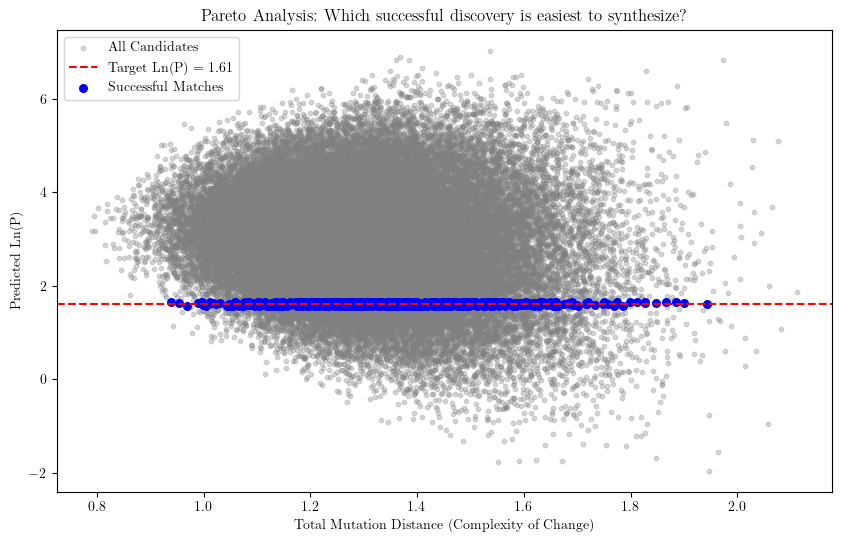

In [114]:
# 1. Calculate the 'Total Mutation Distance' for every candidate
# We use the scaled features to calculate the Euclidean distance from the parent
parent_scaled_vec = base_sample_scaled[Features].values
mutation_distances = np.linalg.norm(candidates_scaled[Features].values - parent_scaled_vec, axis=1)

# 2. Add this to our analysis dataframe
candidates_scaled['Mutation_Distance'] = mutation_distances
candidates_scaled['Ln_P'] = np.log(candidates_scaled['Predicted_P_MPa'])

# 3. Plot the Pareto Front: Mutation Distance vs. Pressure Accuracy
plt.figure(figsize=(10, 6))
plt.scatter(candidates_scaled['Mutation_Distance'], candidates_scaled['Ln_P'],
            alpha=0.3, c='gray', s=10, label='All Candidates')

# Highlight the Pareto Front (closest to target Ln(P) with lowest distance)
target_lnp = np.log(5.0)
plt.axhline(target_lnp, color='red', linestyle='--', label='Target Ln(P) = 1.61')

# Filter candidates very close to the target
target_matches = candidates_scaled[np.abs(candidates_scaled['Ln_P'] - target_lnp) < 0.05]
plt.scatter(target_matches['Mutation_Distance'], target_matches['Ln_P'],
            c='blue', s=30, label='Successful Matches')

plt.xlabel('Total Mutation Distance (Complexity of Change)')
plt.ylabel('Predicted Ln(P)')
plt.title('Pareto Analysis: Which successful discovery is easiest to synthesize?')
plt.legend()
plt.show()

In [119]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist

# 1. Filter for accuracy (within 1% of 5.0 MPa)
accuracy_threshold = 0.01
successful_candidates = candidates_scaled[
    np.abs(candidates_scaled['Predicted_P_MPa'] - 5.0) < (5.0 * accuracy_threshold)
].copy()

# 2. Sort by Mutation Distance and pick top 10
pareto_discoveries_scaled = successful_candidates.sort_values('Mutation_Distance').head(10)

# 3. Inverse transform for human-readable units
raw_pareto = scaler.inverse_transform(pareto_discoveries_scaled[Features])
pareto_df = pd.DataFrame(raw_pareto, columns=Features)
pareto_df['Predicted_P_MPa'] = pareto_discoveries_scaled['Predicted_P_MPa'].values
pareto_df['Mutation_Distance'] = pareto_discoveries_scaled['Mutation_Distance'].values

# 4. Identify Closest Real Alloys
composition_names = []
for i in range(len(pareto_df)):
    # Pull the scaled vector for distance calculation
    discovery_vec = pareto_discoveries_scaled.iloc[[i]][Features].values
    # Calculate distance to all real alloys in X
    dists = cdist(discovery_vec, X, metric='euclidean')[0]
    closest_idx = np.argmin(dists)
    composition_names.append(data.iloc[closest_idx]['composition_final'])

pareto_df['Closest_Known_Alloy'] = composition_names

# 5. Final Output
print(f"--- Top 10 Efficient Discoveries for {parent_name} ---")
final_cols = ['Closest_Known_Alloy', 'Mutation_Distance', 'CR', 'HF', 'Mass', 'Predicted_P_MPa']
print(pareto_df[final_cols].round(4))

--- Top 10 Efficient Discoveries for Mg0.68Ni0.23Ti0.09 ---
              Closest_Known_Alloy  Mutation_Distance        CR       HF  \
0  Cr0.47Fe0.06Mn0.09Ti0.34Zr0.03             1.0231  131.9091  18.5049   
1   Cr0.4Fe0.12Mn0.09Ti0.34Zr0.03             1.0470  133.5793  16.3272   
2   Cr0.4Fe0.12Mn0.09Ti0.34Zr0.03             1.0873  134.8194  16.9776   
3   Cr0.4Fe0.12Mn0.09Ti0.34Zr0.03             1.0947  134.7140  18.3194   
4   Cr0.4Fe0.12Mn0.09Ti0.34Zr0.03             1.0950  132.4098  16.7080   
5   Cr0.4Fe0.12Mn0.09Ti0.34Zr0.03             1.1094  131.7770  17.7509   
6   Cr0.4Fe0.12Mn0.09Ti0.34Zr0.03             1.1130  132.1710  17.9306   
7   Cr0.4Fe0.12Mn0.09Ti0.34Zr0.03             1.1160  132.9551  17.0375   
8   Cr0.4Fe0.12Mn0.09Ti0.34Zr0.03             1.1288  130.9589  17.7410   
9   Cr0.4Fe0.12Mn0.09Ti0.34Zr0.03             1.1341  133.4558  16.3943   

      Mass  Predicted_P_MPa  
0  56.3967           4.9757  
1  55.9274           5.0056  
2  56.0688           5.0

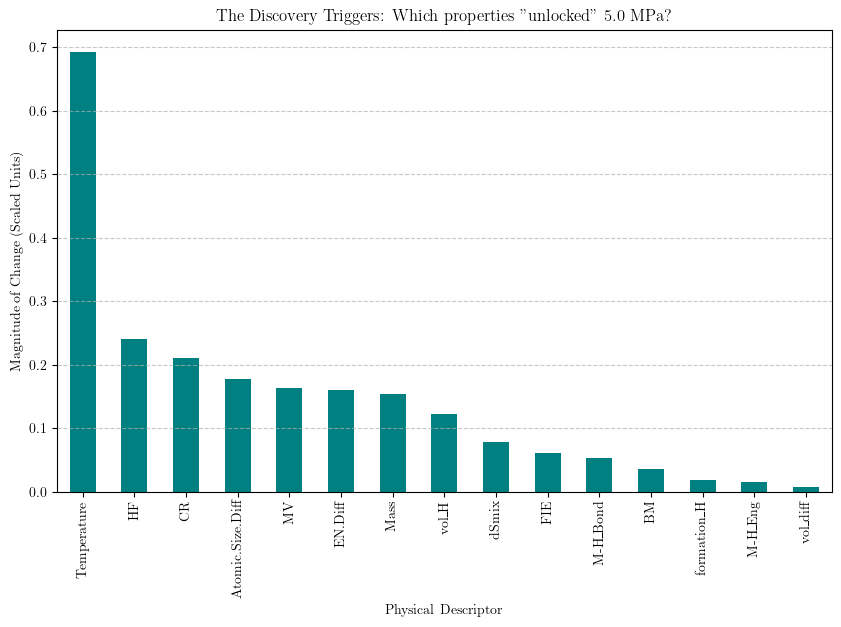

--- Top 3 Synthesis Triggers ---
1. Temperature: Increase (Shift: 0.6934 units)
2. HF: Decrease (Shift: 0.2401 units)
3. CR: Increase (Shift: 0.2101 units)


In [117]:
import matplotlib.pyplot as plt

# 1. Calculate the 'Directional Influence'
# We compare the average of the successful Pareto discoveries to the parent
success_avg = pareto_discoveries_scaled[Features].mean()
parent_profile = base_sample_scaled[Features].iloc[0]

# Calculate the shift (Importance = Magnitude of change in scaled units)
trigger_influence = (success_avg - parent_profile).abs().sort_values(ascending=False)

# 2. Plot the Trigger Ranking
plt.figure(figsize=(10, 6))
trigger_influence.plot(kind='bar', color='teal')
plt.title('The Discovery Triggers: Which properties "unlocked" 5.0 MPa?')
plt.ylabel('Magnitude of Change (Scaled Units)')
plt.xlabel('Physical Descriptor')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("--- Top 3 Synthesis Triggers ---")
for i, (feat, val) in enumerate(trigger_influence.items()):
    direction = "Increase" if success_avg[feat] > parent_profile[feat] else "Decrease"
    print(f"{i+1}. {feat}: {direction} (Shift: {val:.4f} units)")
    if i == 2: break

In [120]:
# 1. Prepare the closest known alloy names as before
composition_names = []
for i in range(len(pareto_df)):
    discovery_vec = pareto_discoveries_scaled.iloc[[i]][Features].values
    dists = cdist(discovery_vec, X, metric='euclidean')[0]
    closest_idx = np.argmin(dists)
    composition_names.append(data.iloc[closest_idx]['composition_final'])

# 2. Compile the final dataframe
final_report = pareto_df.copy()
final_report['Closest_Known_Alloy'] = composition_names

# 3. Save to CSV for your records
final_report.to_csv('Top_10_Hydrogen_Storage_Discoveries.csv', index=False)

# 4. Display the simplified table
cols_to_print = ['Closest_Known_Alloy', 'Mutation_Distance', 'CR', 'HF', 'Mass', 'BM', 'Predicted_P_MPa']
print("--- FINAL DISCOVERY MASTER LIST ---")
print(final_report[cols_to_print].round(3))

--- FINAL DISCOVERY MASTER LIST ---
              Closest_Known_Alloy  Mutation_Distance       CR      HF    Mass  \
0  Cr0.47Fe0.06Mn0.09Ti0.34Zr0.03              1.023  131.909  18.505  56.397   
1   Cr0.4Fe0.12Mn0.09Ti0.34Zr0.03              1.047  133.579  16.327  55.927   
2   Cr0.4Fe0.12Mn0.09Ti0.34Zr0.03              1.087  134.819  16.978  56.069   
3   Cr0.4Fe0.12Mn0.09Ti0.34Zr0.03              1.095  134.714  18.319  55.152   
4   Cr0.4Fe0.12Mn0.09Ti0.34Zr0.03              1.095  132.410  16.708  54.291   
5   Cr0.4Fe0.12Mn0.09Ti0.34Zr0.03              1.109  131.777  17.751  52.138   
6   Cr0.4Fe0.12Mn0.09Ti0.34Zr0.03              1.113  132.171  17.931  55.712   
7   Cr0.4Fe0.12Mn0.09Ti0.34Zr0.03              1.116  132.955  17.038  54.482   
8   Cr0.4Fe0.12Mn0.09Ti0.34Zr0.03              1.129  130.959  17.741  58.457   
9   Cr0.4Fe0.12Mn0.09Ti0.34Zr0.03              1.134  133.456  16.394  53.401   

        BM  Predicted_P_MPa  
0  129.791            4.976  
1  133.030  

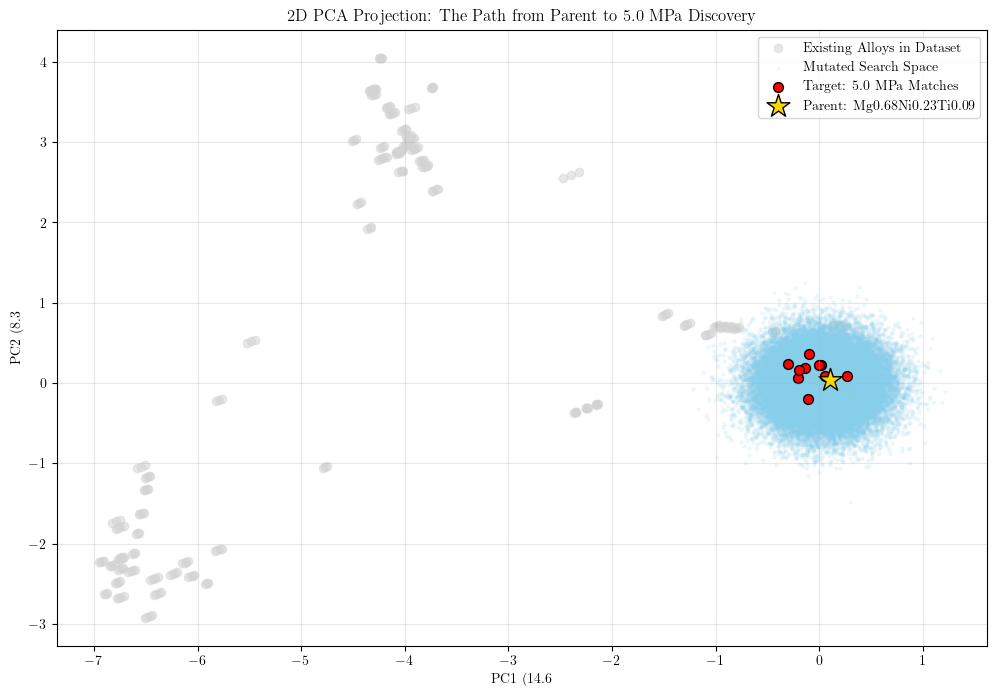

In [121]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Combine Original Data and Mutated Data for a consistent PCA projection
X_combined = pd.concat([X, candidates_scaled[Features]], axis=0)

# 2. Apply PCA to reduce 15 features to 2 components
pca = PCA(n_components=2)
pca_results = pca.fit_transform(X_combined)

# 3. Split the results back into original and mutated
original_pca = pca_results[:len(X)]
mutated_pca = pca_results[len(X):]

# 4. Extract the specific PCA point for your Parent alloy
parent_idx = X_test.index[0] # Adjust this index if your parent was row index 3
parent_pca = pca.transform(X.loc[[parent_idx]])

# 5. Plotting
plt.figure(figsize=(12, 8))

# Plot all original alloys (the background knowledge)
plt.scatter(original_pca[:, 0], original_pca[:, 1], c='lightgray', alpha=0.5, label='Existing Alloys in Dataset')

# Plot the 5000 mutated candidates (the search space)
plt.scatter(mutated_pca[:, 0], mutated_pca[:, 1], c='skyblue', alpha=0.1, s=5, label='Mutated Search Space')

# Highlight the Successful Discoveries (Top 10)
success_pca = pca.transform(pareto_discoveries_scaled[Features])
plt.scatter(success_pca[:, 0], success_pca[:, 1], c='red', s=50, edgecolors='black', label='Target: 5.0 MPa Matches')

# Highlight the Parent Alloy (The starting point)
plt.scatter(parent_pca[:, 0], parent_pca[:, 1], c='gold', marker='*', s=300, edgecolors='black', label=f'Parent: {parent_name}')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('2D PCA Projection: The Path from Parent to 5.0 MPa Discovery')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

   k  mean_mae   std_mae  mean_mse  std_mse   mean_r2    std_r2
0  2  0.303845  0.049385  0.275217  0.09887  0.924508  0.035928
1  3  0.202493  0.032725  0.104133  0.03606  0.973137  0.006793


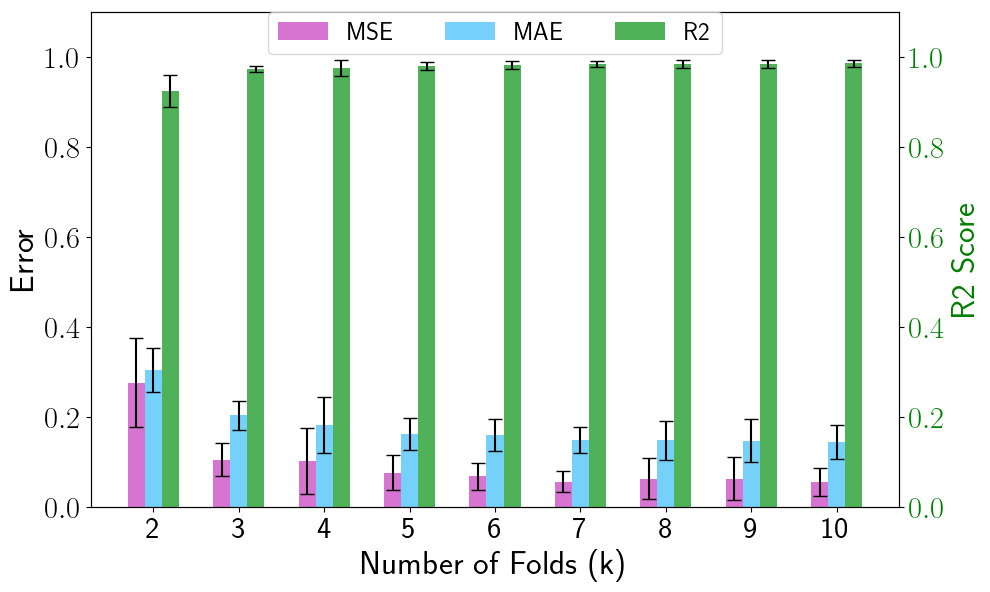

In [36]:
# Evaluate Model for Different K Values
# Run multiple K-fold validations (for K = 2 → 10)
# to see how error metrics change with the number of folds.
# Calculates and stores:
# Mean and standard deviation of MAE, MSE, R²
# Results are stored in a DataFrame (results_df).
# Define metrics and storage

# Visualize Cross-Validation Metrics
# Create a bar plot showing:
# MAE and MSE (left y-axis)
# R² (right y-axis)
# for each k value.
# This helps compare model stability as the number of folds varies.

scoring = {
    'mae': 'neg_mean_absolute_error',
    'mse': 'neg_mean_squared_error',
    'r2': 'r2'
}
k_values = np.arange(2,11,1)
results = []

# Iterate over different k values
for k in k_values:
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    # Run cross-validation once for all metrics
    cv_results = cross_validate(kr, X, y, cv=kf, scoring=scoring)

    # Compute mean and std for each metric
    mean_mae = -np.mean(cv_results['test_mae'])
    std_mae = np.std(cv_results['test_mae'])
    mean_mse = -np.mean(cv_results['test_mse'])
    std_mse = np.std(cv_results['test_mse'])
    mean_r2 = np.mean(cv_results['test_r2'])
    std_r2 = np.std(cv_results['test_r2'])

    # Store results in a structured format
    results.append({
        'k': k,
        'mean_mae': mean_mae,
        'std_mae': std_mae,
        'mean_mse': mean_mse,
        'std_mse': std_mse,
        'mean_r2': mean_r2,
        'std_r2': std_r2
    })

# Convert to DataFrame for easy plotting and analysis
results_df = pd.DataFrame(results)
print(results_df.head(2))

fig, ax1 = plt.subplots(figsize=(10, 6))
plt.xticks(k_values, k_values, fontsize=22)
# Bar plot with error bars for Mean Absolute Error (MAE)
bar_width = 0.2
ax1.set_ylim(0, 1.1)
k_values_shifted = k_values - bar_width
ax1.bar(k_values_shifted, results_df['mean_mse'], width=bar_width, yerr=results_df['std_mse'], capsize=5, color='#C738BD', alpha=0.7, label='MSE')
ax1.bar(k_values, results_df['mean_mae'], width=bar_width, yerr=results_df['std_mae'], capsize=5, color='#3ABEF9', alpha=0.7, label='MAE')
ax1.set_xlabel('Number of Folds (k)', fontsize=24)
ax1.set_ylabel('Error', fontsize=24)
ax1.tick_params(axis='y', labelsize=22)

ax2 = ax1.twinx()
ax2.set_ylim(0, 1.2)
ax2.bar(k_values + bar_width, results_df['mean_r2'], width=bar_width, yerr=results_df['std_r2'], capsize=5, color='#059212', alpha=0.7, label='R2')
ax2.set_ylabel('R2 Score', color='g', fontsize=24)
ax2.tick_params(axis='y', labelcolor='g', labelsize=22)
plt.ylim(0,1.1)

# Add legend
fig.legend(loc='upper center',shadow=False, ncol=3, fontsize=18)

plt.tight_layout()
#plt.savefig('OUTPUT/KRR_ML_K-fold.png',format='png',dpi=800, bbox_inches='tight')
plt.show()

# ***#Step 5: SHAP (Feature Importance) Analysis***
###Compute SHAP values to explain model predictions
###Generate SHAP summary plots and bar plots
###Rank features by mean absolute SHAP value (importance)
###This provides insight into which physical or chemical descriptors most strongly influence equilibrium pressure



In [38]:
import shap
# SHAP Explainer
model=KernelRidge(kernel='rbf', alpha = 0.001, gamma = 0.1)
model.fit(X_train, y_train)
explainer = shap.KernelExplainer(model.predict,X_train)
shap_values = explainer(X_test)


  0%|          | 0/59 [00:00<?, ?it/s]

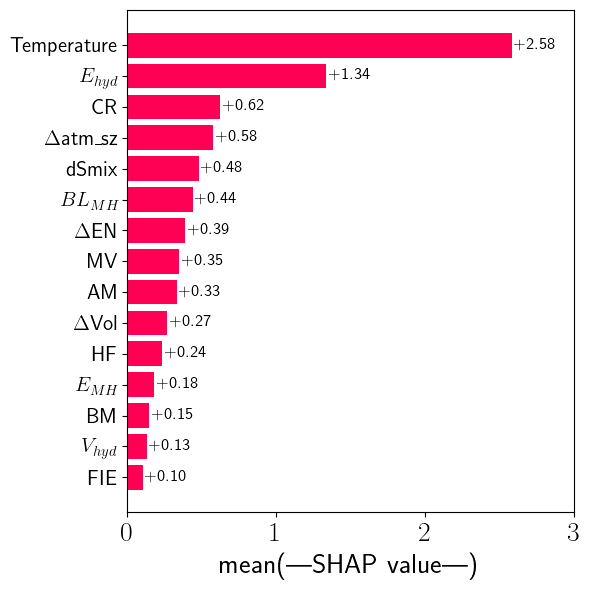

In [39]:
mean_shap = np.abs(shap_values.values).mean(axis=0)
feature_names = X_test.columns
# Sort by importance
sorted_idx = np.argsort(mean_shap)[::-1]
sorted_means = mean_shap[sorted_idx]
sorted_features = [r'Temperature', r'$E_{hyd}$', r'CR', r'$\Delta$atm_sz', r'dSmix',
            r'$BL_{MH}$', r'$\Delta$EN', r'MV', r'AM', r'$\Delta$Vol', r'HF',
             r'$E_{MH}$', r'BM', r'$V_{hyd}$', r'FIE']
# Bar plot manually (instead of shap.plots.bar)
fig, ax = plt.subplots(figsize=(6, 6))
plt.locator_params(nbins=5)
ax.barh(range(len(sorted_means)), sorted_means, align="center",color= "#ff0055")
ax.set_yticks(range(len(sorted_means)))
ax.set_yticklabels(sorted_features,fontsize=15)
ax.invert_yaxis()  # most important at top
ax.set_xlabel("mean(|SHAP value|)",fontsize=20)
# Add SHAP values at the end of bars
for i, v in enumerate(sorted_means):
    ax.text(v + 0.01, i, f"{ v:+.2f}", va="center", fontsize=12)
plt.xlim(0,3)
plt.xticks(fontsize=20)
plt.tight_layout()

#plt.savefig('OUTPUT/SHAP_FI.png',format='png',dpi=800, bbox_inches='tight')
plt.show()

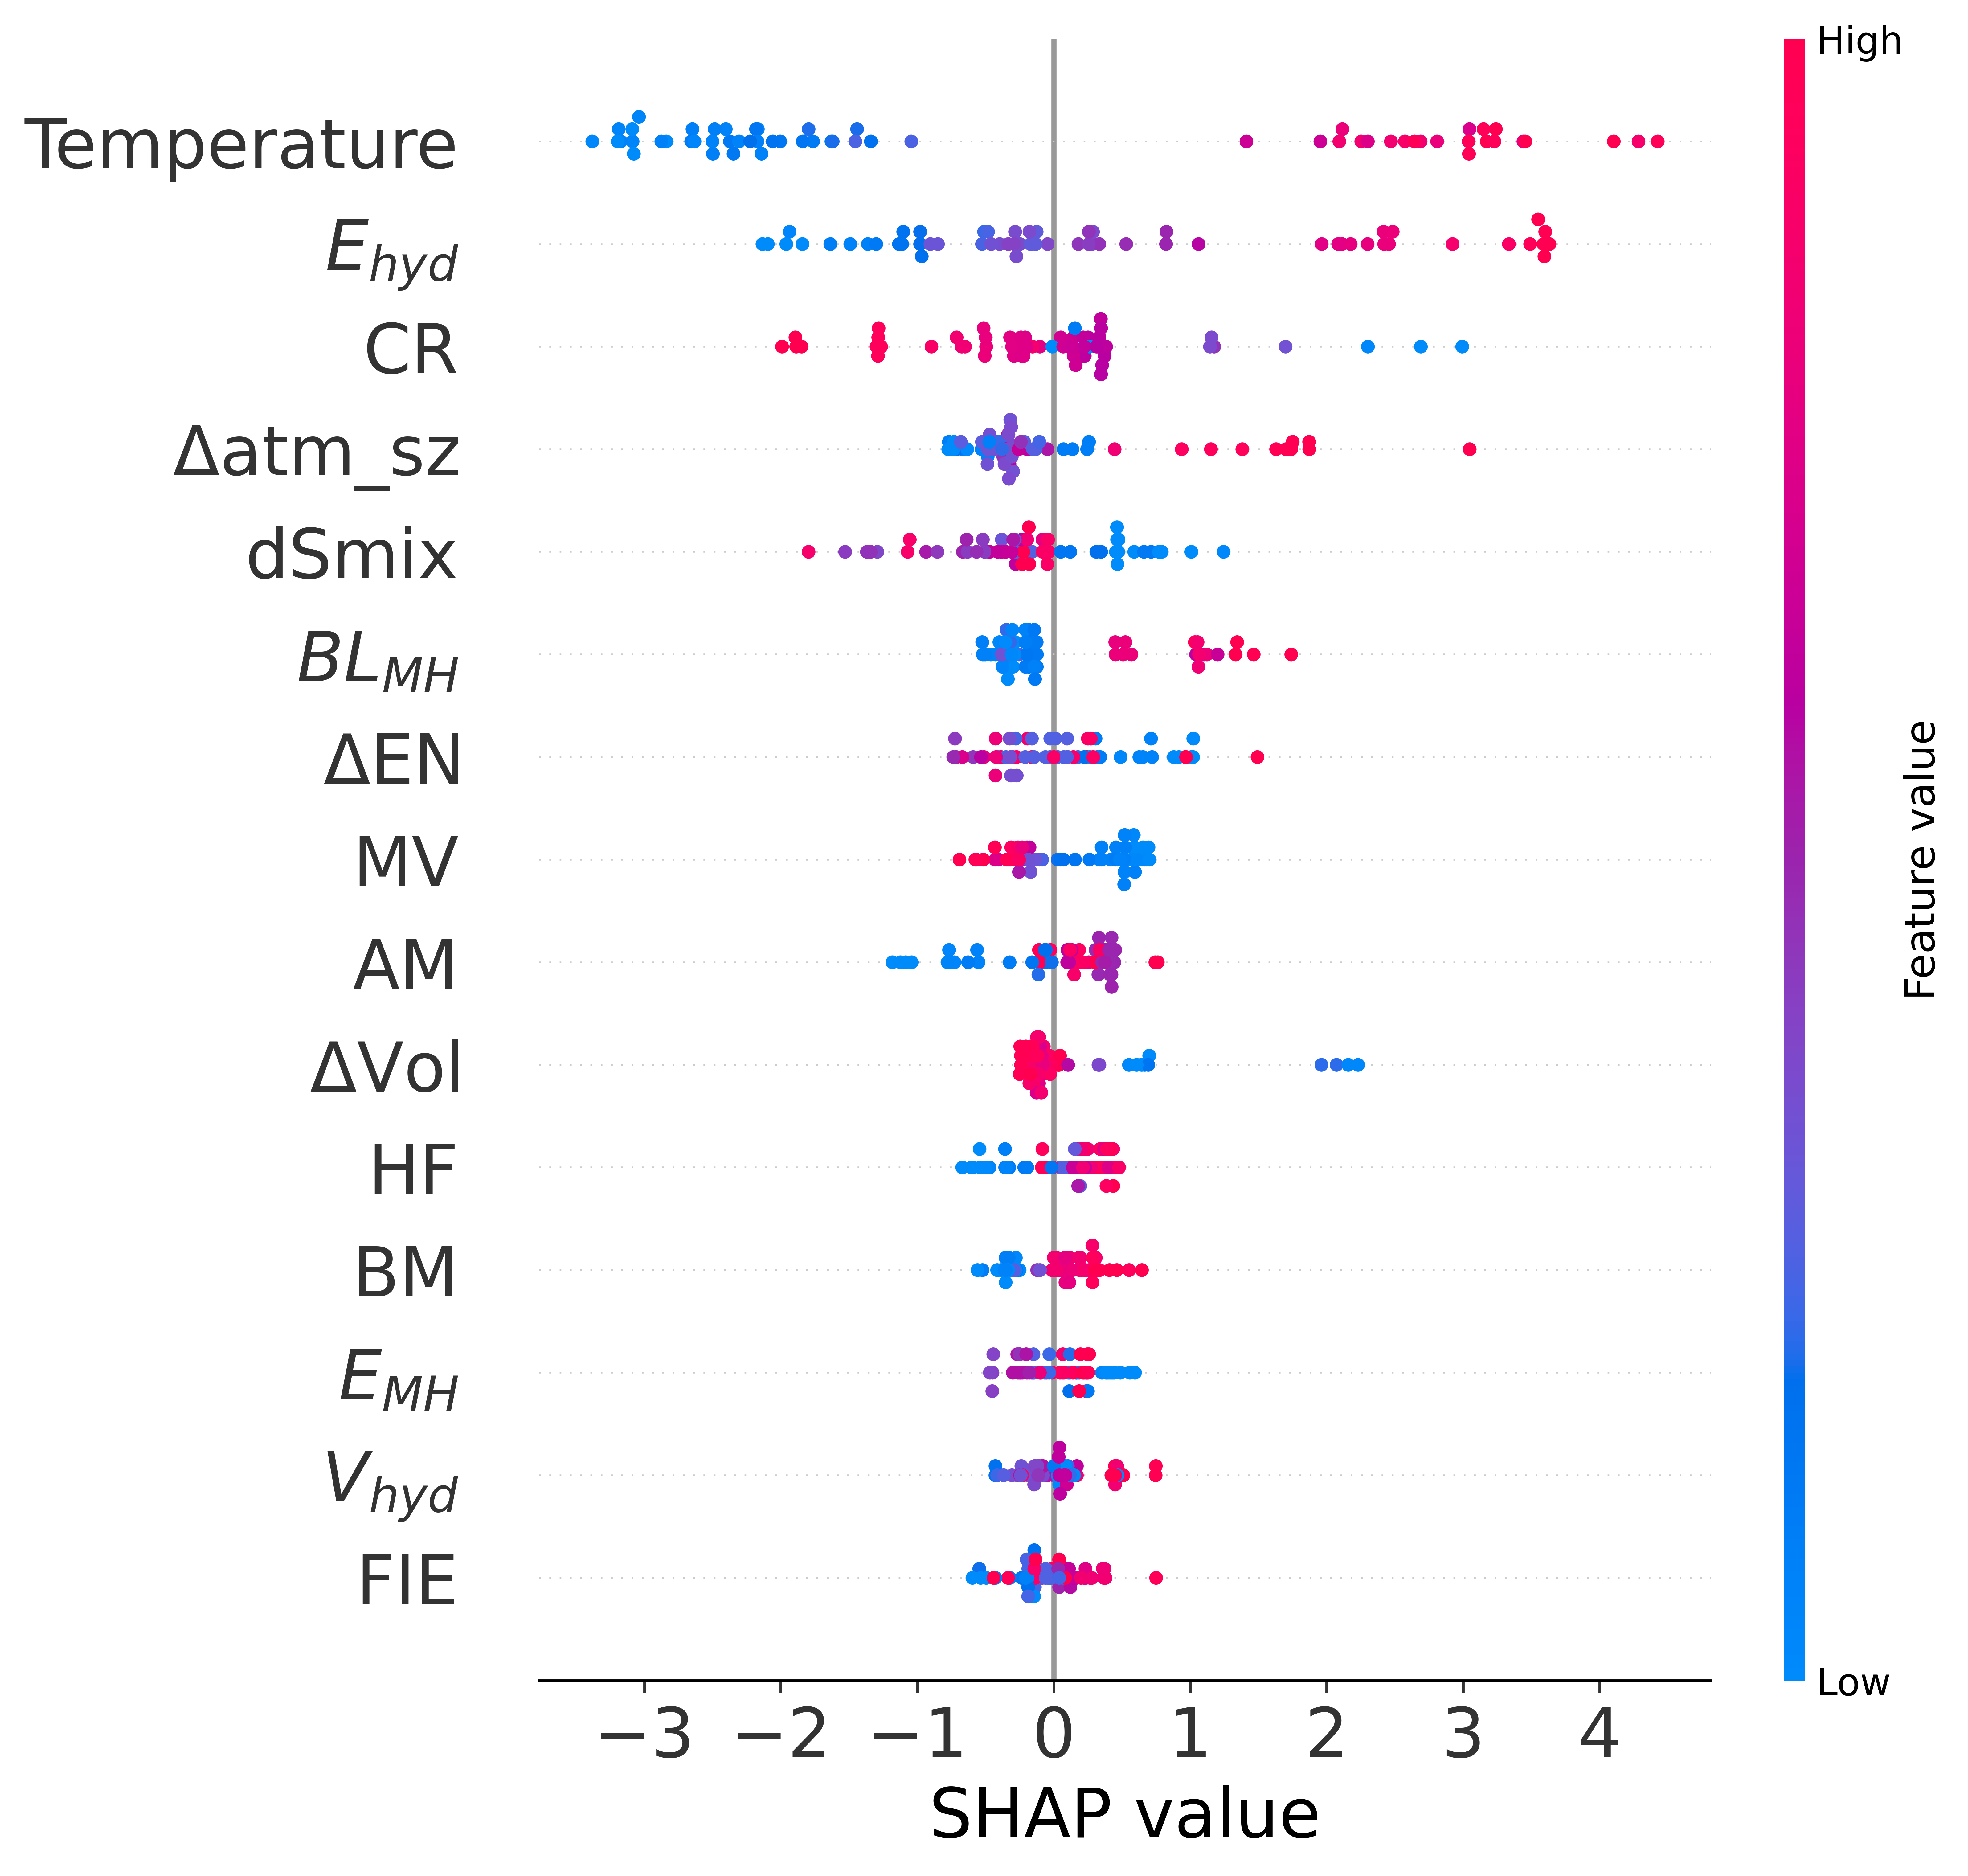

# **#Step 7: Leave-One-Composition-Out (LOCO) Analysis**
### Iteratively removes one composition from training
### train model on n-1 compositions
### Predicts Peq for removed composition using the rest of the data
### Compares predicted vs. experimental P–T relationships
### Estimates ΔH (enthalpy) and ΔS (entropy) via Van’t Hoff fits
### Plots are generated showing both experimental and model-predicted trends for each composition.

In [41]:
from scipy.stats import linregress
import warnings
warnings.filterwarnings('ignore')

col1=['Temperature', 'CR',
       'FIE',  'BM', 'HF', 'MV',  'Mass',
    'M-H_Bond', 'M-H_Eng',    'formation_H',
       'vol_H',  'vol_diff', 'EN.Diff',
       'Atomic.Size.Diff', 'dSmix']
dff = []
unique_entries = data.drop_duplicates(['composition_final'])
test=data

loco_results = [] # List to store LOCO analysis results

for xx in range(0,len(unique_entries)):
    q=unique_entries[xx:xx+1]
    compostion = q['composition_final']
    com=compostion.values[0]
    print(f"Analyzing composition: {com}") # Added print statement
    TEST=data[(data["composition_final"]==com)]
    TRAIN= data.drop(TEST.index)

    X_train1 = TRAIN[col1]
    y_train1 = TRAIN["Ln(P)_Mpa"]

    #Input and Target
    X_test1 = TEST[col1]
    y_test1 = TEST["Ln(P)_Mpa"]



    clf1=KernelRidge(kernel='rbf', alpha = 0.001, gamma = 0.1)
    clf1.fit(X_train1, y_train1)
    TEST['ML_KRR']=clf1.predict(X_test1)

    plt.figure(figsize=(10,6))
    plt.rcParams['font.family'] = 'Serif'
    plt.locator_params(nbins=4)
    plt.xticks(fontsize=25,)
    plt.yticks(fontsize=25)
    slope, intercept, _, _, _ = linregress(1000/(TEST['Temperature_1']),np.log(10*np.exp(TEST['Ln(P)_Mpa'])))
    sl1= slope*8.314
    in1= intercept*8.314
    plt.scatter(1000/(TEST['Temperature_1']),np.log(10*np.exp(TEST['Ln(P)_Mpa'])), marker='o',color='black')
    plt.plot((1000/(TEST['Temperature_1'])), slope*(1000/(TEST['Temperature_1'])) + intercept, 'ko-', linewidth=2, markersize=0, color='black', label=f'Expt. (ΔH: {sl1:.2f} ; ΔS: - {in1:.2f} )')

    slope1, intercept1, _, _, _ = linregress(1000/(TEST['Temperature_1']),np.log(10*np.exp(TEST['ML_KRR'])))
    sl2= slope1*8.314
    in2= intercept1*8.314
    plt.scatter(1000/(TEST['Temperature_1']),np.log(10*np.exp(TEST['ML_KRR'])),marker='^',color='red')
    plt.plot(1000/(TEST['Temperature_1']), slope1*(1000/(TEST['Temperature_1'])) + intercept1, 'r^-', linewidth=2, markersize=0, label=f'EquiP (ΔH: {sl2:.2f} ({np.abs(np.abs(sl1)-np.abs(sl2)):.2f}); ΔS: - {in2:.2f} ({in1-in2:.2f})) ')

    plt.xlabel(r'$1000/T$ (K$^{-1}$)', fontsize=25)
    plt.ylabel(r'$\ln(P)$ (bar)', fontsize=25)
    plt.legend(loc="upper right",frameon=False,fontsize=20)
    plt.tight_layout()
    plt.show()

    loco_results.append({
        'composition': com,
        'Exp_Enthalpy': sl1,
        'Exp_Entropy': in1,
        'ML_Enthalpy': sl2,
        'ML_Entropy': in2
    })

Va = pd.DataFrame(loco_results)


Analyzing composition: Mg0.95Sn0.03Zn0.02


RuntimeError: latex was not able to process the following string:
b'Expt. (\\u0394H: -66.27 ; \\u0394S: - 122.46 )'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpth7th0yz c9796783f5d82ecdc48046a9743e08ad.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.22 (TeX Live 2022/dev/Debian) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./c9796783f5d82ecdc48046a9743e08ad.tex
LaTeX2e <2021-11-15> patch level 1
L3 programming layer <2022-01-21>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2021/10/04 v1.4n Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texmf/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/share/texlive/texmf-dist/tex/l

Error in callback <function _draw_all_if_interactive at 0x7c4f0b2e6840> (for post_execute):


RuntimeError: latex was not able to process the following string:
b'Expt. (\\u0394H: -66.27 ; \\u0394S: - 122.46 )'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpclacyb_i c9796783f5d82ecdc48046a9743e08ad.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.22 (TeX Live 2022/dev/Debian) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./c9796783f5d82ecdc48046a9743e08ad.tex
LaTeX2e <2021-11-15> patch level 1
L3 programming layer <2022-01-21>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2021/10/04 v1.4n Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texmf/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/share/texlive/texmf-dist/tex/l

RuntimeError: latex was not able to process the following string:
b'Expt. (\\u0394H: -66.27 ; \\u0394S: - 122.46 )'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmp0zb3uafi c9796783f5d82ecdc48046a9743e08ad.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.22 (TeX Live 2022/dev/Debian) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./c9796783f5d82ecdc48046a9743e08ad.tex
LaTeX2e <2021-11-15> patch level 1
L3 programming layer <2022-01-21>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2021/10/04 v1.4n Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texmf/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/share/texlive/texmf-dist/tex/l

<Figure size 1000x600 with 1 Axes>

In [42]:
display(Va)

NameError: name 'Va' is not defined

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 8))
sns.scatterplot(x='Exp_Enthalpy', y='ML_Enthalpy', data=Va, s=100, hue='composition', palette='viridis', legend='full')
plt.plot([Va['Exp_Enthalpy'].min(), Va['Exp_Enthalpy'].max()],
         [Va['Exp_Enthalpy'].min(), Va['Exp_Enthalpy'].max()],
         'k--', lw=2, label='Perfect Fit')
plt.title('Experimental vs. Predicted Enthalpy (ΔH)')
plt.xlabel('Experimental ΔH (kJ/mol)')
plt.ylabel('Predicted ΔH (kJ/mol)')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 8))
sns.scatterplot(x='Exp_Entropy', y='ML_Entropy', data=Va, s=100, hue='composition', palette='viridis', legend='full')
plt.plot([Va['Exp_Entropy'].min(), Va['Exp_Entropy'].max()],
         [Va['Exp_Entropy'].min(), Va['Exp_Entropy'].max()],
         'k--', lw=2, label='Perfect Fit')
plt.title('Experimental vs. Predicted Entropy (ΔS)')
plt.xlabel('Experimental ΔS (J/(mol·K))')
plt.ylabel('Predicted ΔS (J/(mol·K))')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Va['Delta_Enthalpy'] = np.abs(Va['Exp_Enthalpy'] - Va['ML_Enthalpy'])
Va['Delta_Entropy'] = np.abs(Va['Exp_Entropy'] - Va['ML_Entropy'])

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(Va['Delta_Enthalpy'], bins=15, kde=True)
plt.title('Distribution of Absolute ΔH Difference')
plt.xlabel('Absolute ΔH Difference (kJ/mol)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(Va['Delta_Entropy'], bins=15, kde=True)
plt.title('Distribution of Absolute ΔS Difference')
plt.xlabel('Absolute ΔS Difference (J/(mol·K))')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
import joblib
# Save model to file
joblib.dump(model, "krr_model.pkl")
print("Model saved as krr_model.pkl")

Model saved as krr_model.pkl


In [ ]:
# Load model
loaded_model = joblib.load("krr_model.pkl")

# Test the loaded model
y_pred = loaded_model.predict(X_test)
print("Experiment:", round(y_test.values[0],4))
print("Prediction:", round(y_pred[0],4))

Experiment: 0.3042
Prediction: 0.3851


# **Examples to train multiple ML architectures (Random Forest, CNN, RNN, LSTM, Transformer) for molecular property prediction using open-access datasets.**

In [ ]:
pip install rdkit torch torchvision torchaudio torchtext torch-geometric scikit-learn pandas numpy tqdm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.2/36.2 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 75.0 MB/s eta 0:00:00


In [ ]:
#Load & Preprocess Data (QM9 via PyTorch Geometric)
from torch_geometric.datasets import QM9
from torch_geometric.loader import DataLoader
import torch